# Predicting Earthquake Damage to Prioritise Building Inspections
### Richter's Predictor (2015 Gorkha earthquake, Nepal) — logistic regression study

**Problem statement.** *Can we predict how badly a building was damaged in the 2015 Gorkha earthquake from its structure and location, so post-disaster inspectors can prioritise which buildings to assess first?*

This notebook is the single, end-to-end narrative of the project. It

1. loads and verifies the data, makes a stratified 80/20 train/holdout split;
2. explores the data (figures saved to `figures/`);
3. runs experiments E0–E6 with stratified 5-fold CV on the 80% training split, all preprocessing inside an sklearn `Pipeline` (no leakage);
4. tunes `C` with `GridSearchCV`, evaluates the chosen model **once** on the holdout;
5. turns predictions into an inspection-prioritisation analysis and interprets coefficients;
6. refits on all labelled data and writes the DrivenData submission;
7. writes every reported number to `outputs/results.json` (the report and slides read only from that file).

Reusable code lives in `src/` (`data.py`, `features.py`, `models.py`, `evaluate.py`, `plots.py`).

In [1]:
import os, sys, json, platform, time, warnings
from dataclasses import asdict
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
# make `src` importable inside joblib worker processes too
os.environ["PYTHONPATH"] = str(ROOT) + os.pathsep + os.environ.get("PYTHONPATH", "")

import numpy as np
import pandas as pd
import sklearn, matplotlib, seaborn
from IPython.display import Image, display
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import GridSearchCV

from src.data import (RANDOM_STATE, TARGET, ID_COL, CLASSES, AGE_PLACEHOLDER, RESULTS_PATH,
                      SUBMISSION_PATH, load_labelled, load_test, split_xy, train_holdout_split,
                      cv_splitter)
from src.features import ENGINEERED_CANDIDATES, GEO_COLS
from src.models import E0, E1, E2, E3, MAX_ITER, make_model, max_n_iter
from src.evaluate import (run_cv, classification_summary, capture_curve, grade3_coefficients,
                          n_iter_scorer, save_results)
from src import plots

# Any ConvergenceWarning raised in this process (e.g. the final refits) becomes an error.
# CV folds run in worker processes, so for those we record solver iterations instead.
warnings.simplefilter("error", ConvergenceWarning)
N_JOBS = int(os.environ.get("N_JOBS", 2))   # parallel CV folds (RAM-limited machine)
T_START = time.time()

results = {"meta": {
    "random_state": RANDOM_STATE, "python": platform.python_version(),
    "sklearn": sklearn.__version__, "pandas": pd.__version__, "numpy": np.__version__,
    "matplotlib": matplotlib.__version__, "seaborn": seaborn.__version__,
    "cv": "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)",
    "solver": "lbfgs", "max_iter": MAX_ITER,
}}
print({k: v for k, v in results["meta"].items()})

{'random_state': 42, 'python': '3.11.14', 'sklearn': '1.5.2', 'pandas': '2.2.3', 'numpy': '2.1.3', 'matplotlib': '3.9.2', 'seaborn': '0.13.2', 'cv': 'StratifiedKFold(n_splits=5, shuffle=True, random_state=42)', 'solver': 'lbfgs', 'max_iter': 5000}


## 1. Load and verify the data
The brief lists some 'known' facts; we verify each one rather than assume it.

In [2]:
df = load_labelled()
test_df = load_test()
feature_cols = [c for c in df.columns if c not in (ID_COL, TARGET)]

class_share = df[TARGET].value_counts(normalize=True).sort_index()
facts = {
    "n_train_rows": int(len(df)), "n_test_rows": int(len(test_df)),
    "n_features": len(feature_cols),
    "n_missing_train": int(df.isna().sum().sum()), "n_missing_test": int(test_df.isna().sum().sum()),
    "class_counts": {str(k): int(v) for k, v in df[TARGET].value_counts().sort_index().items()},
    "class_share": {str(k): float(v) for k, v in class_share.items()},
    "n_age_placeholder": int((df["age"] == AGE_PLACEHOLDER).sum()),
    "share_age_placeholder": float((df["age"] == AGE_PLACEHOLDER).mean()),
    "n_unique": {c: int(df[c].nunique()) for c in GEO_COLS},
    "n_categorical": int((df[feature_cols].dtypes == object).sum()),
    "n_binary": int(sum(set(df[c].unique()) <= {0, 1} for c in feature_cols)),
    "age_max_real": int(df.loc[df["age"] != AGE_PLACEHOLDER, "age"].max()),
    "test_geo3_unseen_share": float((~test_df["geo_level_3_id"].isin(df["geo_level_3_id"])).mean()),
}
assert facts["n_train_rows"] == 260_601 and facts["n_test_rows"] == 86_868
assert facts["n_missing_train"] == 0 and facts["n_missing_test"] == 0
assert abs(facts["class_share"]["2"] - 0.57) < 0.01 and abs(facts["class_share"]["3"] - 0.34) < 0.01
assert abs(facts["n_age_placeholder"] - 1390) < 50
results["data"] = facts
pd.Series({k: v for k, v in facts.items() if not isinstance(v, dict)})

n_train_rows              260601.000000
n_test_rows                86868.000000
n_features                    38.000000
n_missing_train                0.000000
n_missing_test                 0.000000
n_age_placeholder           1390.000000
share_age_placeholder          0.005334
n_categorical                  8.000000
n_binary                      22.000000
age_max_real                 200.000000
test_geo3_unseen_share         0.003764
dtype: float64

In [3]:
print("class share:", {k: round(v, 4) for k, v in facts["class_share"].items()})
print("unique geo ids:", facts["n_unique"])
df.head(3).T.head(15)

class share: {'1': 0.0964, '2': 0.5689, '3': 0.3347}
unique geo ids: {'geo_level_1_id': 31, 'geo_level_2_id': 1414, 'geo_level_3_id': 11595}


,0,1,2
building_id,802906,28830,94947
geo_level_1_id,6,8,21
geo_level_2_id,487,900,363
geo_level_3_id,12198,2812,8973
count_floors_pre_eq,2,2,2
age,30,10,10
area_percentage,6,8,5
height_percentage,5,7,5
land_surface_condition,t,o,t
foundation_type,r,r,r


All the stated facts hold: no missing values, a 9.6% / 56.9% / 33.5% class split, 1,390 buildings with the placeholder age 995, and 11,595 distinct `geo_level_3_id` values.
Eight columns are categorical (anonymised single-letter codes) and the `has_*` columns are binary flags.

## 2. Stratified 80/20 train / holdout split
The holdout is locked away until Section 8. All model selection below uses stratified 5-fold CV on the 80% split. EDA is also done on the training split only, so nothing we learn about the data comes from the holdout.

In [4]:
train_df, holdout_df = train_holdout_split(df)
X_tr, y_tr = split_xy(train_df)
X_ho, y_ho = split_xy(holdout_df)
results["split"] = {
    "n_train": int(len(train_df)), "n_holdout": int(len(holdout_df)),
    "train_class_share": {str(k): float(v) for k, v in y_tr.value_counts(normalize=True).sort_index().items()},
    "holdout_class_share": {str(k): float(v) for k, v in y_ho.value_counts(normalize=True).sort_index().items()},
}
results["split"]

{'n_train': 208480,
 'n_holdout': 52121,
 'train_class_share': {'1': 0.09640732924021489,
  '2': 0.5689130851880276,
  '3': 0.3346795855717575},
 'holdout_class_share': {'1': 0.09641027608833291,
  '2': 0.5689069664818404,
  '3': 0.3346827574298267}}

## 3. Exploratory data analysis (training split)

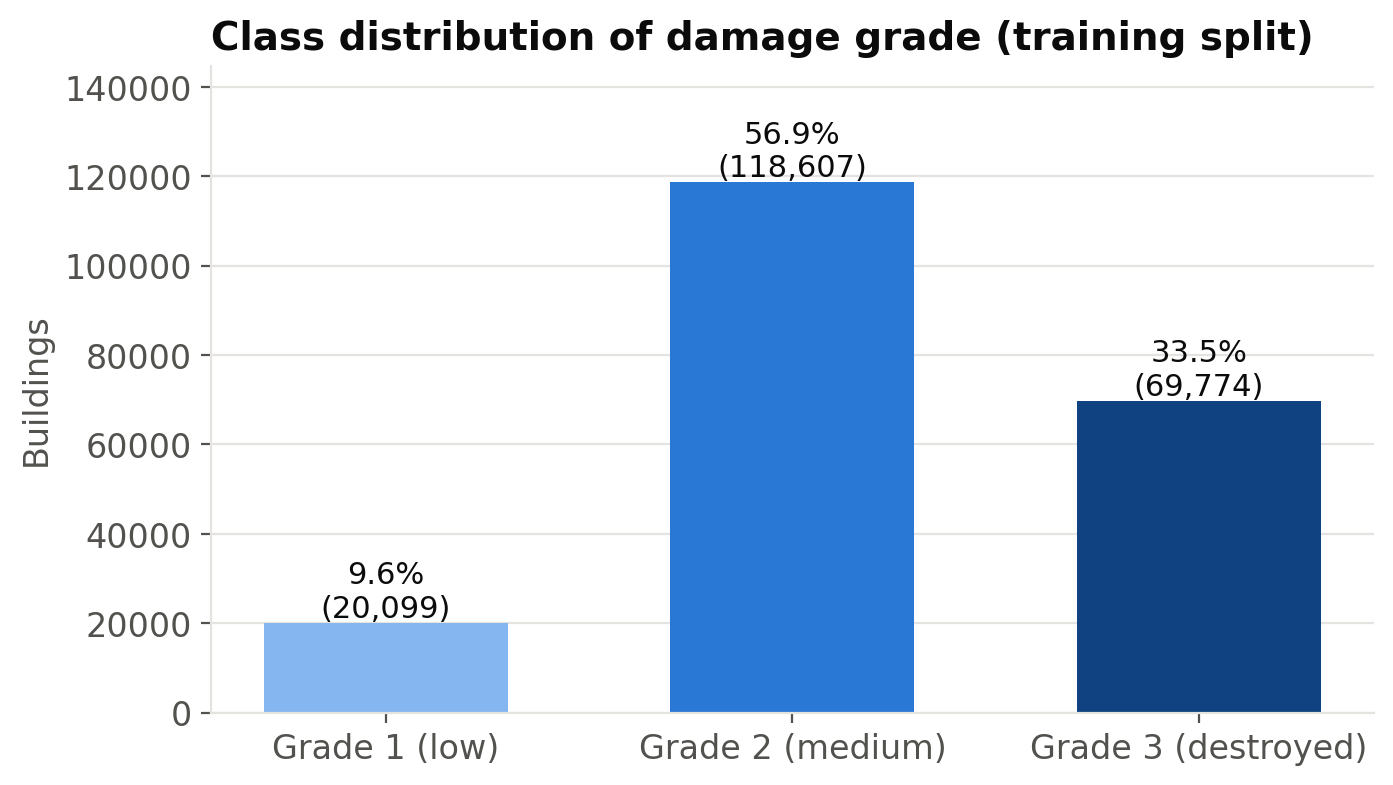

In [5]:
display(Image(plots.plot_class_distribution(y_tr), width=650))

**Takeaway.** Grade 2 dominates (≈57%), grade 3 is ≈33% and grade 1 only ≈10%. A model that always predicts grade 2 already scores ≈0.57 micro-F1, so that is the bar to beat, and grade 1 will be the hardest class to recall.

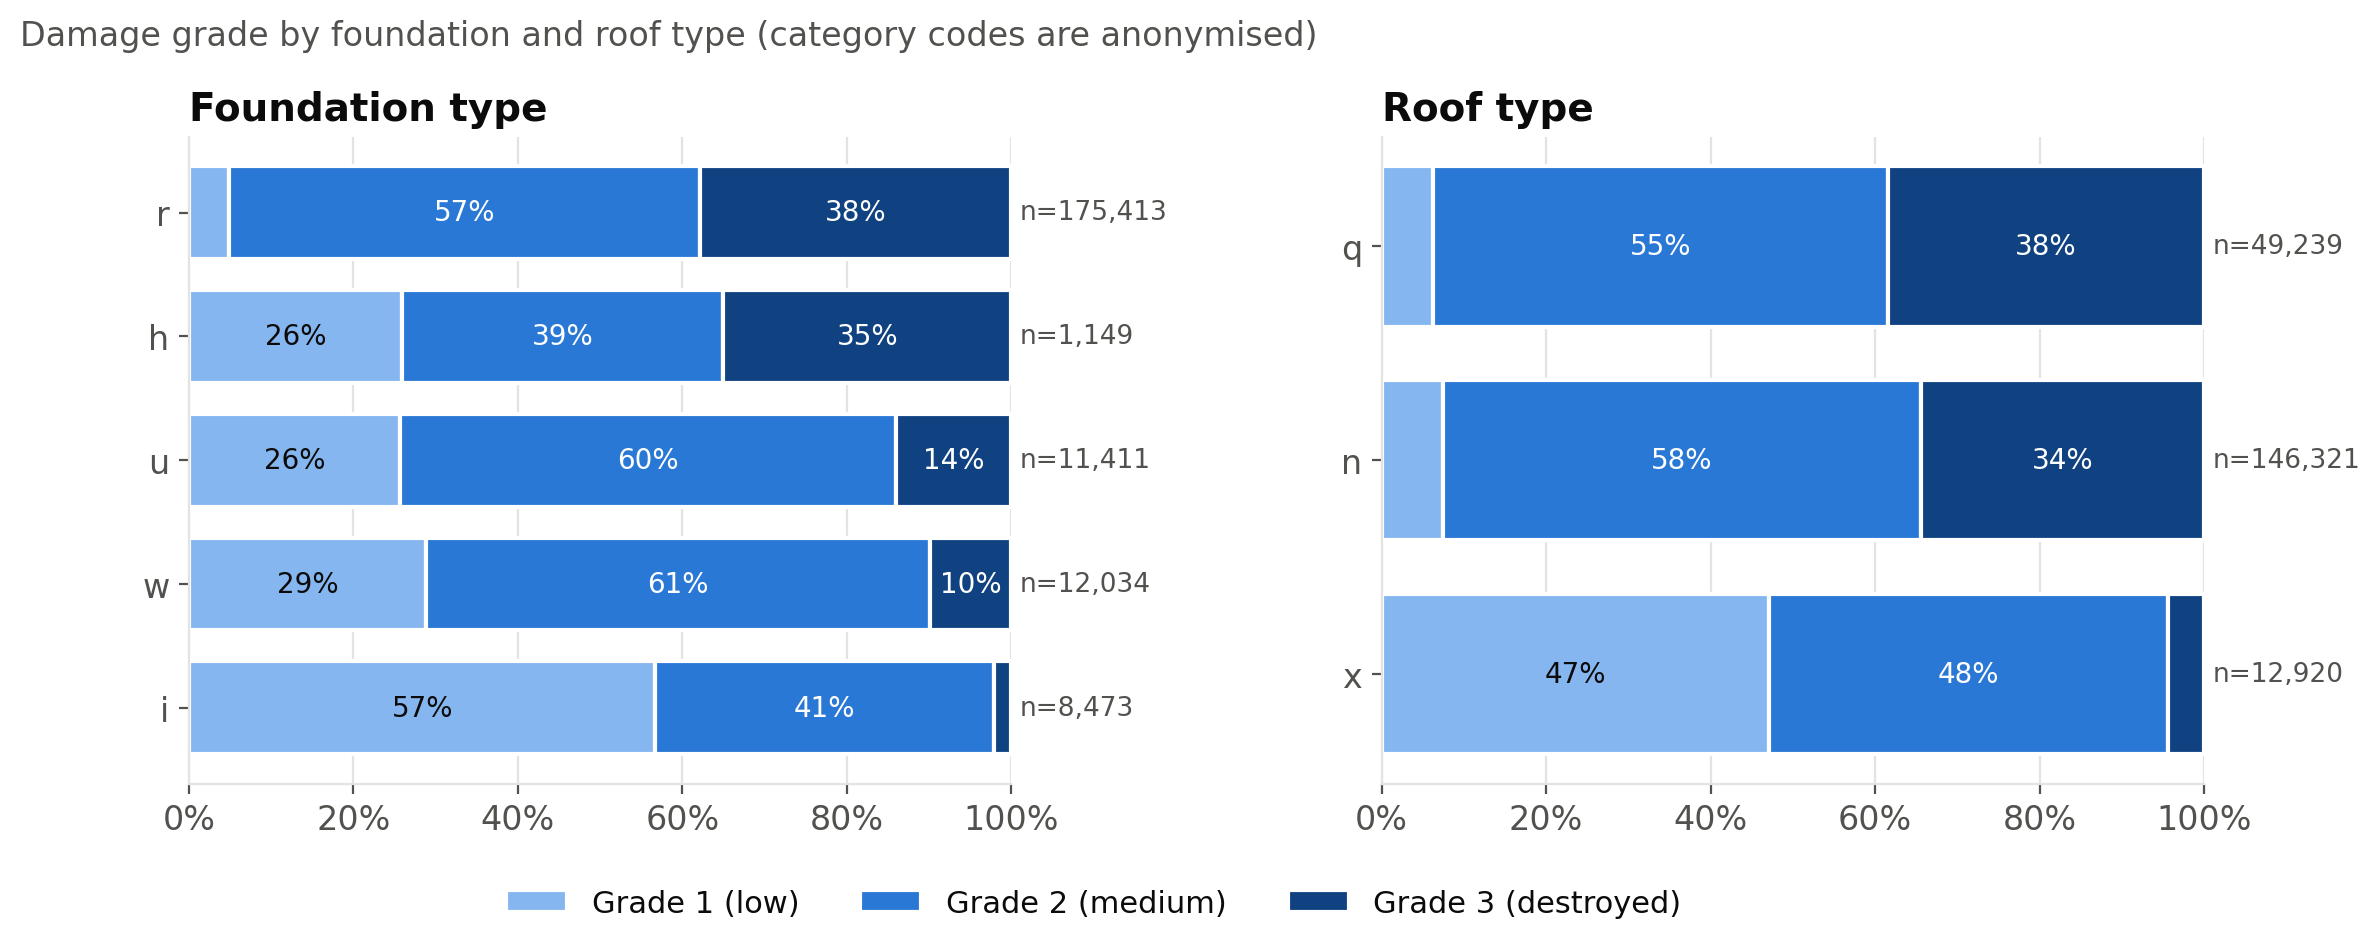

,grade3_share,grade1_share,prevalence
h,0.3507,0.2594,0.0055
i,0.0210,0.5670,0.0406
r,0.3785,0.0491,0.8414
u,0.1407,0.2562,0.0547
w,0.0989,0.2882,0.0577


In [6]:
display(Image(plots.plot_damage_by_foundation_roof(train_df), width=1000))
eda = {}
for col in ["foundation_type", "roof_type", "ground_floor_type"]:
    tab = pd.crosstab(train_df[col], train_df[TARGET], normalize="index")
    eda[col] = {"grade3_share": tab[3].round(4).to_dict(), "grade1_share": tab[1].round(4).to_dict(),
                "prevalence": train_df[col].value_counts(normalize=True).round(4).to_dict()}
pd.DataFrame(eda["foundation_type"])

**Takeaway.** Construction type separates the classes sharply. Foundation `r`, used by ~84% of buildings, has ≈38% grade-3 damage, while foundation `i` has ≈2% grade 3 and ≈57% grade 1. Roof `x` has ≈4% grade 3, against 34–38% for roofs `n` and `q`. The codes are anonymised, but `i` and `x` behave like engineered (reinforced-concrete) construction.

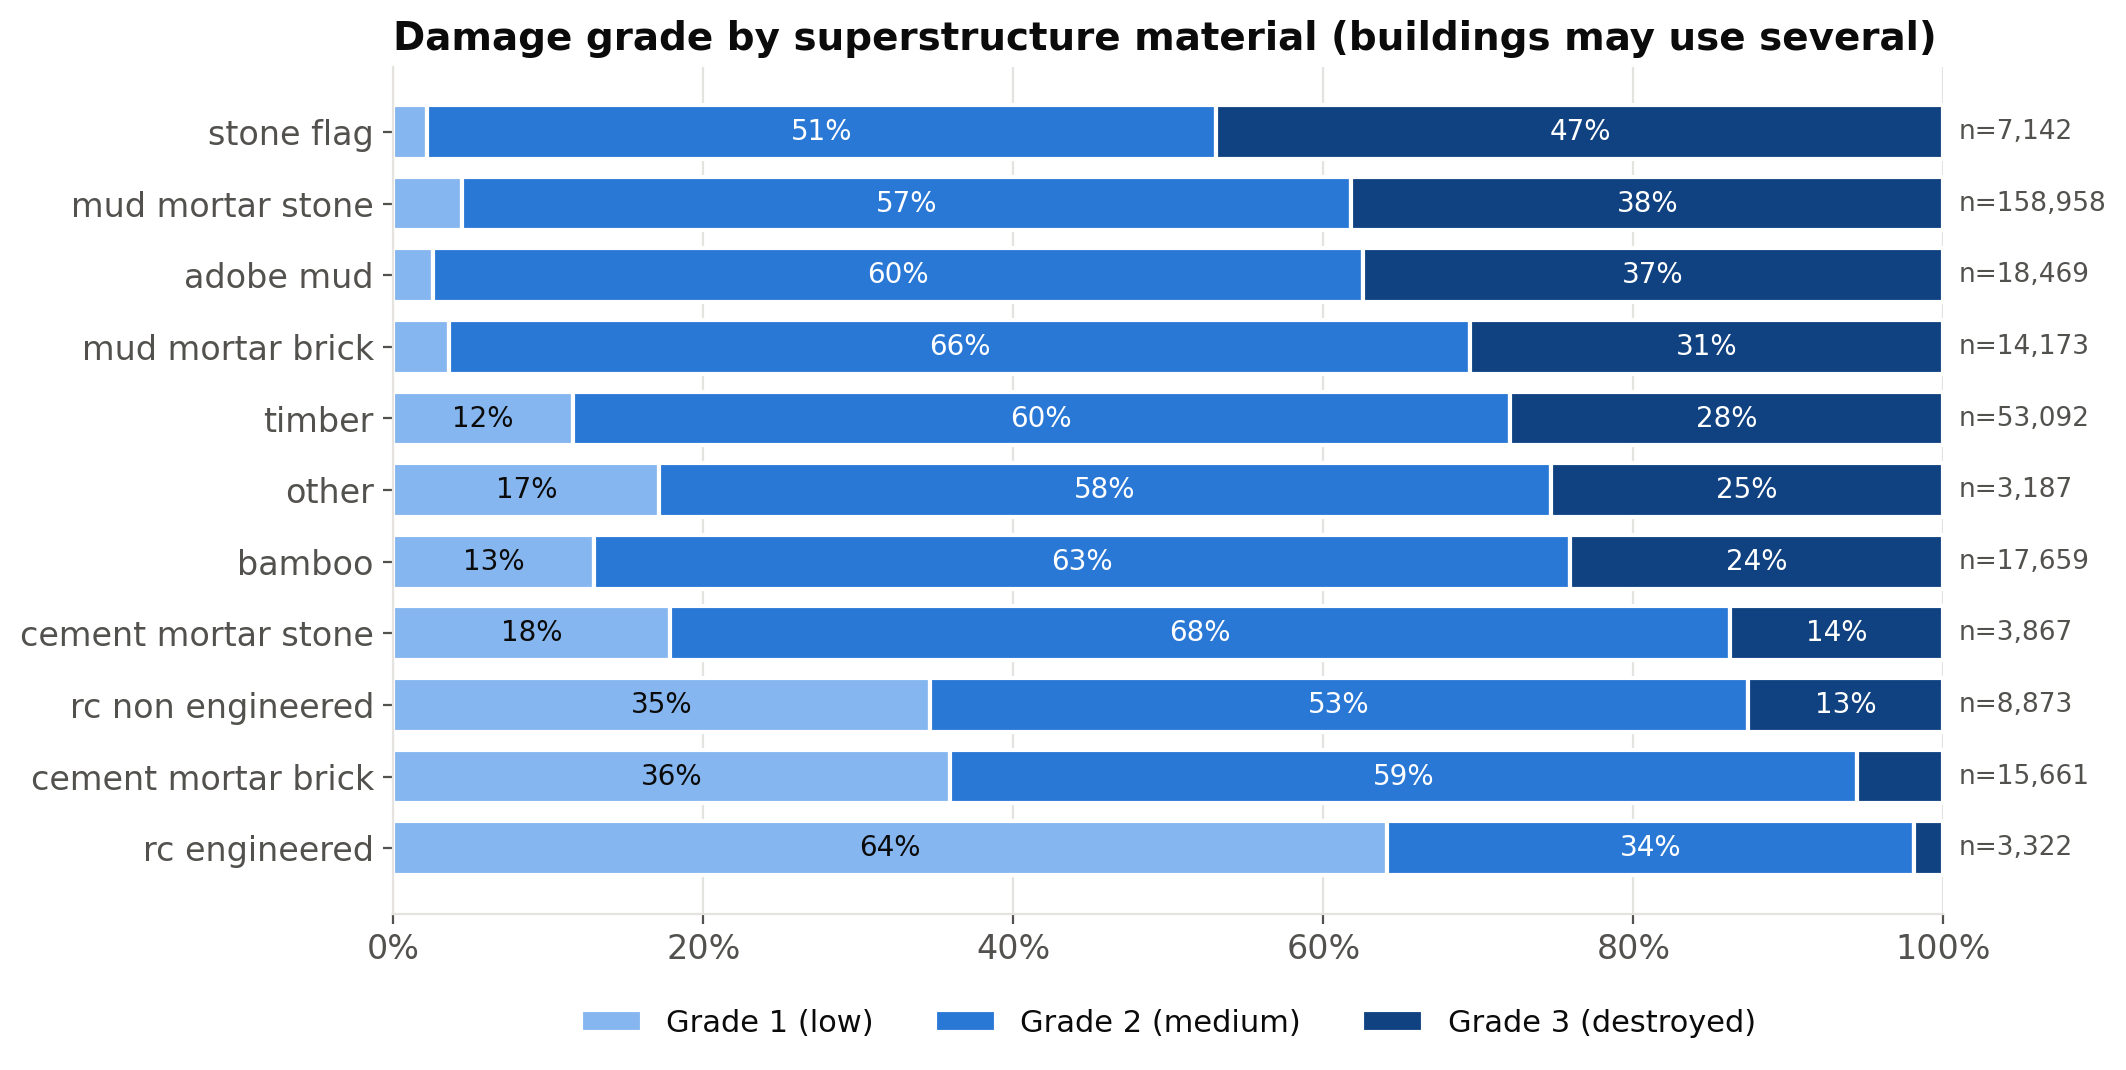

,grade3_share,grade1_share,prevalence
has_superstructure_rc_engineered,0.019,0.641,0.016
has_superstructure_cement_mortar_brick,0.056,0.359,0.075
has_superstructure_rc_non_engineered,0.126,0.346,0.043
has_superstructure_cement_mortar_stone,0.138,0.179,0.019
has_superstructure_bamboo,0.241,0.129,0.085
has_superstructure_other,0.253,0.172,0.015
has_superstructure_timber,0.280,0.116,0.255
has_superstructure_mud_mortar_brick,0.306,0.036,0.068
has_superstructure_adobe_mud,0.375,0.026,0.089
has_superstructure_mud_mortar_stone,0.382,0.044,0.762


In [7]:
display(Image(plots.plot_superstructure(train_df), width=850))
ss = {c: {"grade3_share": float(train_df.loc[train_df[c] == 1, TARGET].eq(3).mean()),
          "grade1_share": float(train_df.loc[train_df[c] == 1, TARGET].eq(1).mean()),
          "prevalence": float(train_df[c].mean())}
      for c in train_df.columns if c.startswith("has_superstructure_")}
eda["superstructure"] = ss
pd.DataFrame(ss).T.sort_values("grade3_share").round(3)

**Takeaway.** Mud-mortar stone is the most common material (≈76% of buildings) and ≈38% of those buildings were destroyed. Stone-flag and adobe-mud buildings fare as badly or worse. Engineered reinforced concrete (RC) has only ≈2% grade 3 and ≈64% grade 1, and cement-mortar brick has ≈6% grade 3. Material is the clearest structural signal in the data.

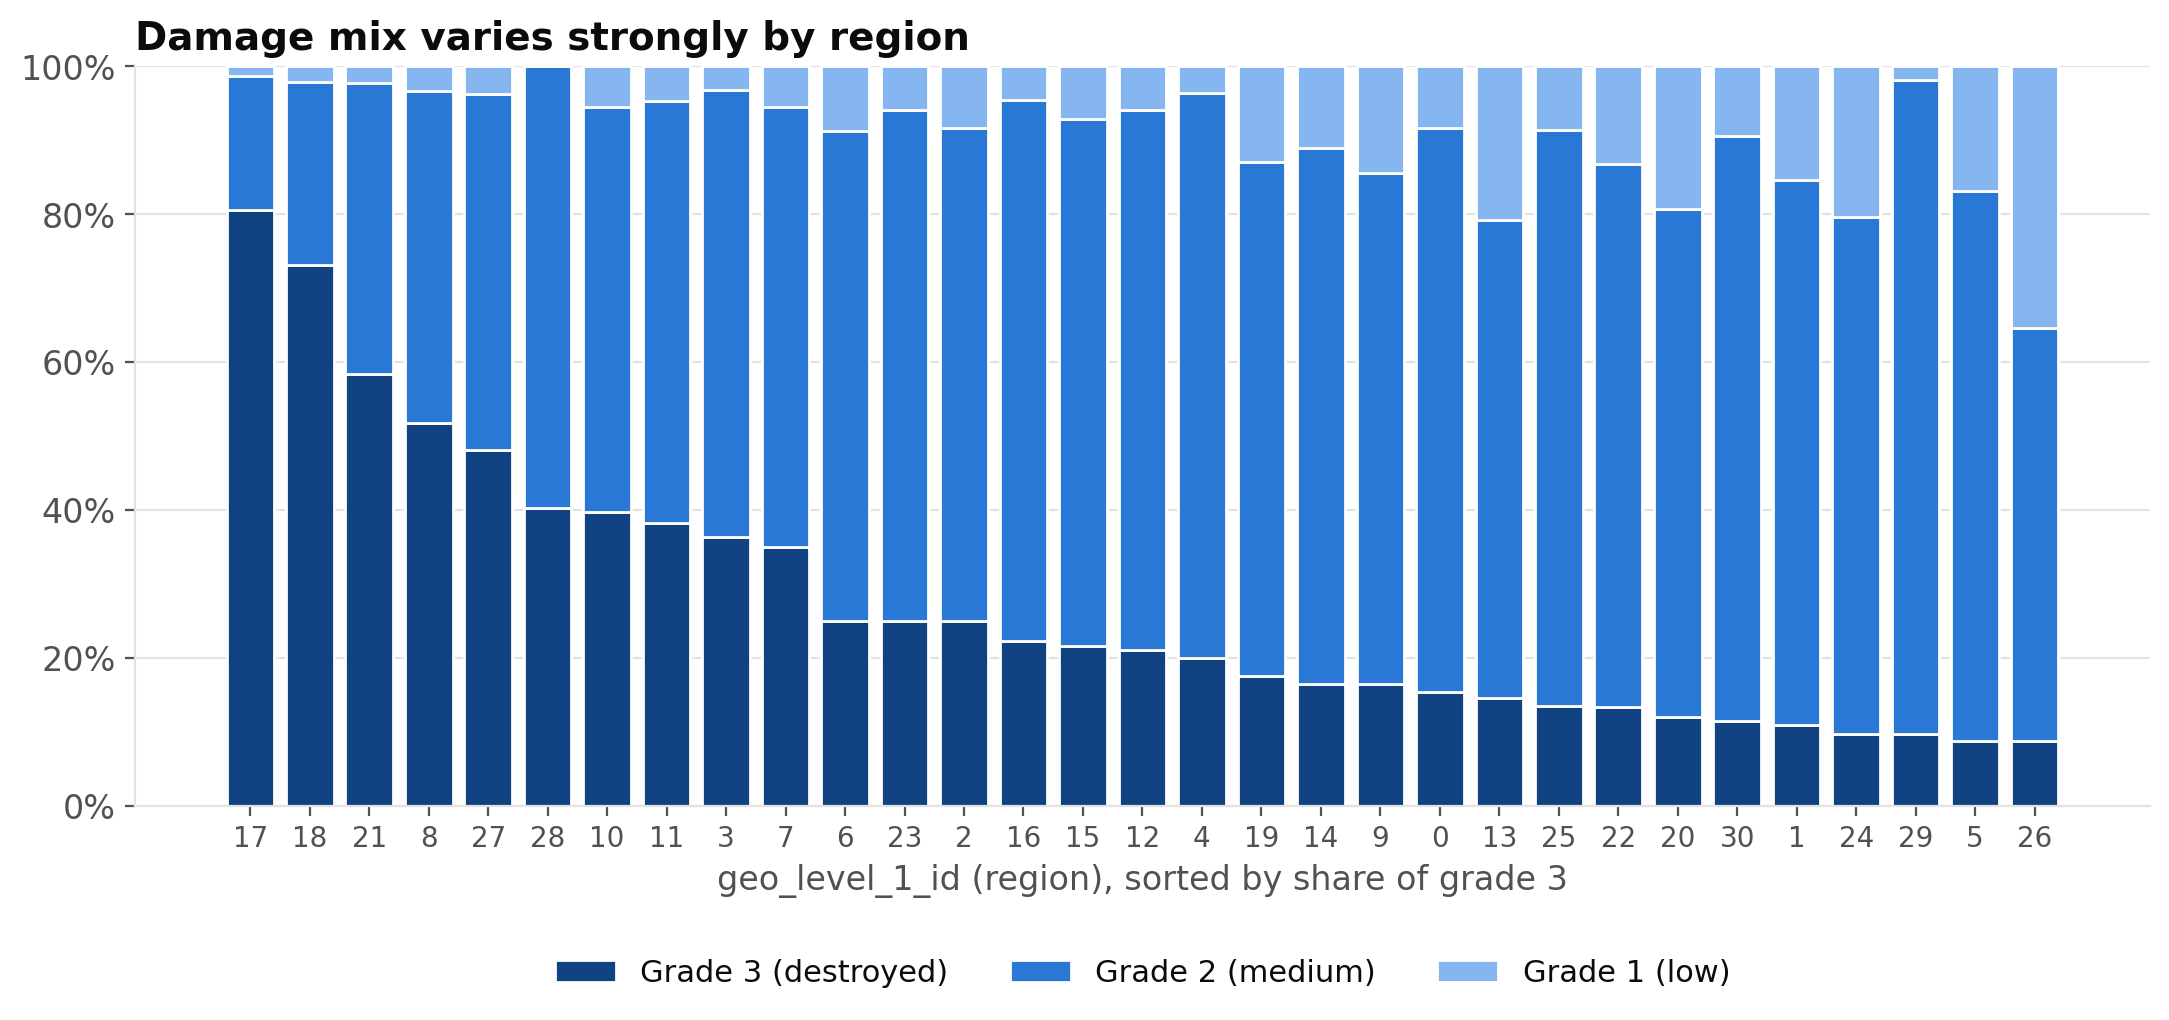

{'min': 0.08754021968268057,
 'max': 0.8063923796407872,
 'argmin': 26,
 'argmax': 17}

In [8]:
display(Image(plots.plot_damage_by_geo1(train_df), width=1000))
g1 = pd.crosstab(train_df["geo_level_1_id"], train_df[TARGET], normalize="index")[3]
eda["geo1_grade3_share"] = {"min": float(g1.min()), "max": float(g1.max()),
                            "argmin": int(g1.idxmin()), "argmax": int(g1.idxmax())}
eda["geo1_grade3_share"]

**Takeaway.** Location matters at least as much as structure. The grade-3 share runs from ≈9% in region 26 to ≈81% in region 17, which most likely reflects shaking intensity and distance from the epicentre. Including geography, and finer geographic levels in particular, should give a large gain.

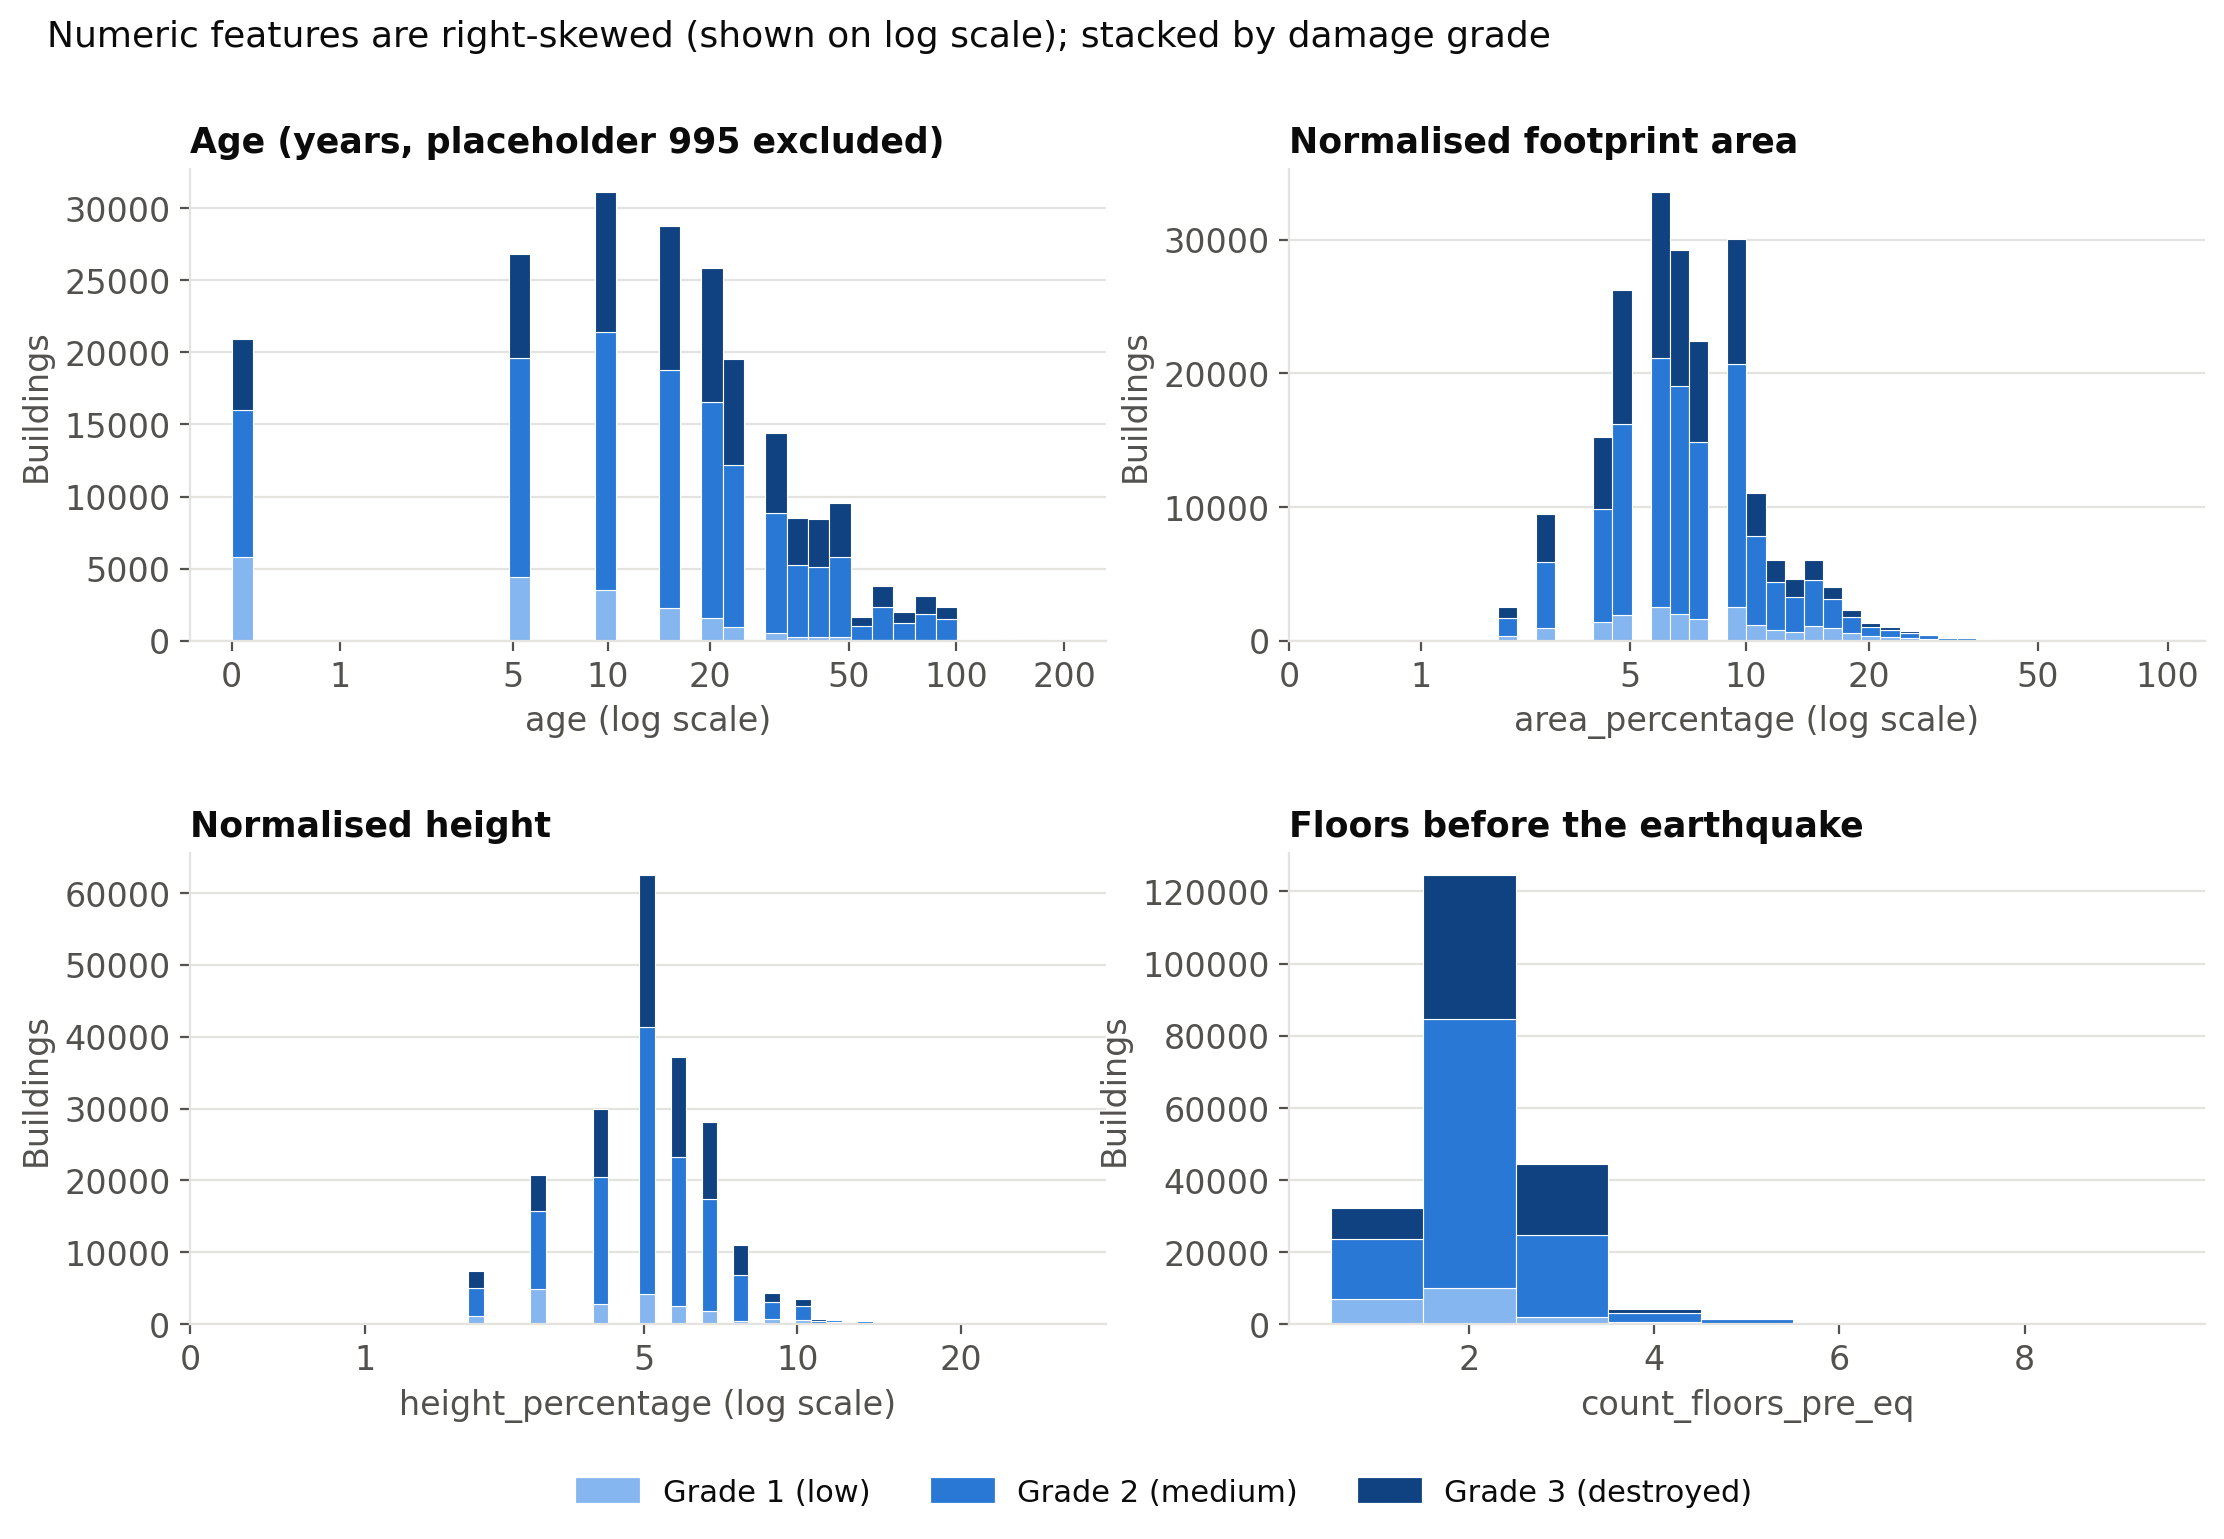

,skew,skew_after_log1p
age,2.047,-1.036
area_percentage,3.521,0.411
height_percentage,1.733,-0.151
count_floors_pre_eq,0.819,NaN


In [9]:
display(Image(plots.plot_numeric_distributions(train_df), width=1000))
num = ["age", "area_percentage", "height_percentage", "count_floors_pre_eq"]
real_age = train_df[train_df["age"] != AGE_PLACEHOLDER]
eda["skewness"] = real_age[num].skew().round(3).to_dict()
eda["skewness_after_log1p"] = np.log1p(real_age[num[:3]]).skew().round(3).to_dict()
ph = train_df["age"] == AGE_PLACEHOLDER
eda["age_placeholder_grade3_share"] = float(train_df.loc[ph, TARGET].eq(3).mean())
eda["age_real_grade3_share"] = float(train_df.loc[~ph, TARGET].eq(3).mean())
pd.DataFrame({"skew": eda["skewness"], "skew_after_log1p": eda["skewness_after_log1p"]})

**Takeaway.** Age, area and height are strongly right-skewed (skewness ≈2.1, 3.5 and 1.7), and `log1p` brings them much closer to symmetric, which suits a linear model. The placeholder-age buildings have a lower grade-3 share (≈29% vs ≈34%), so we keep an indicator flag for them rather than treating 995 as a real age.

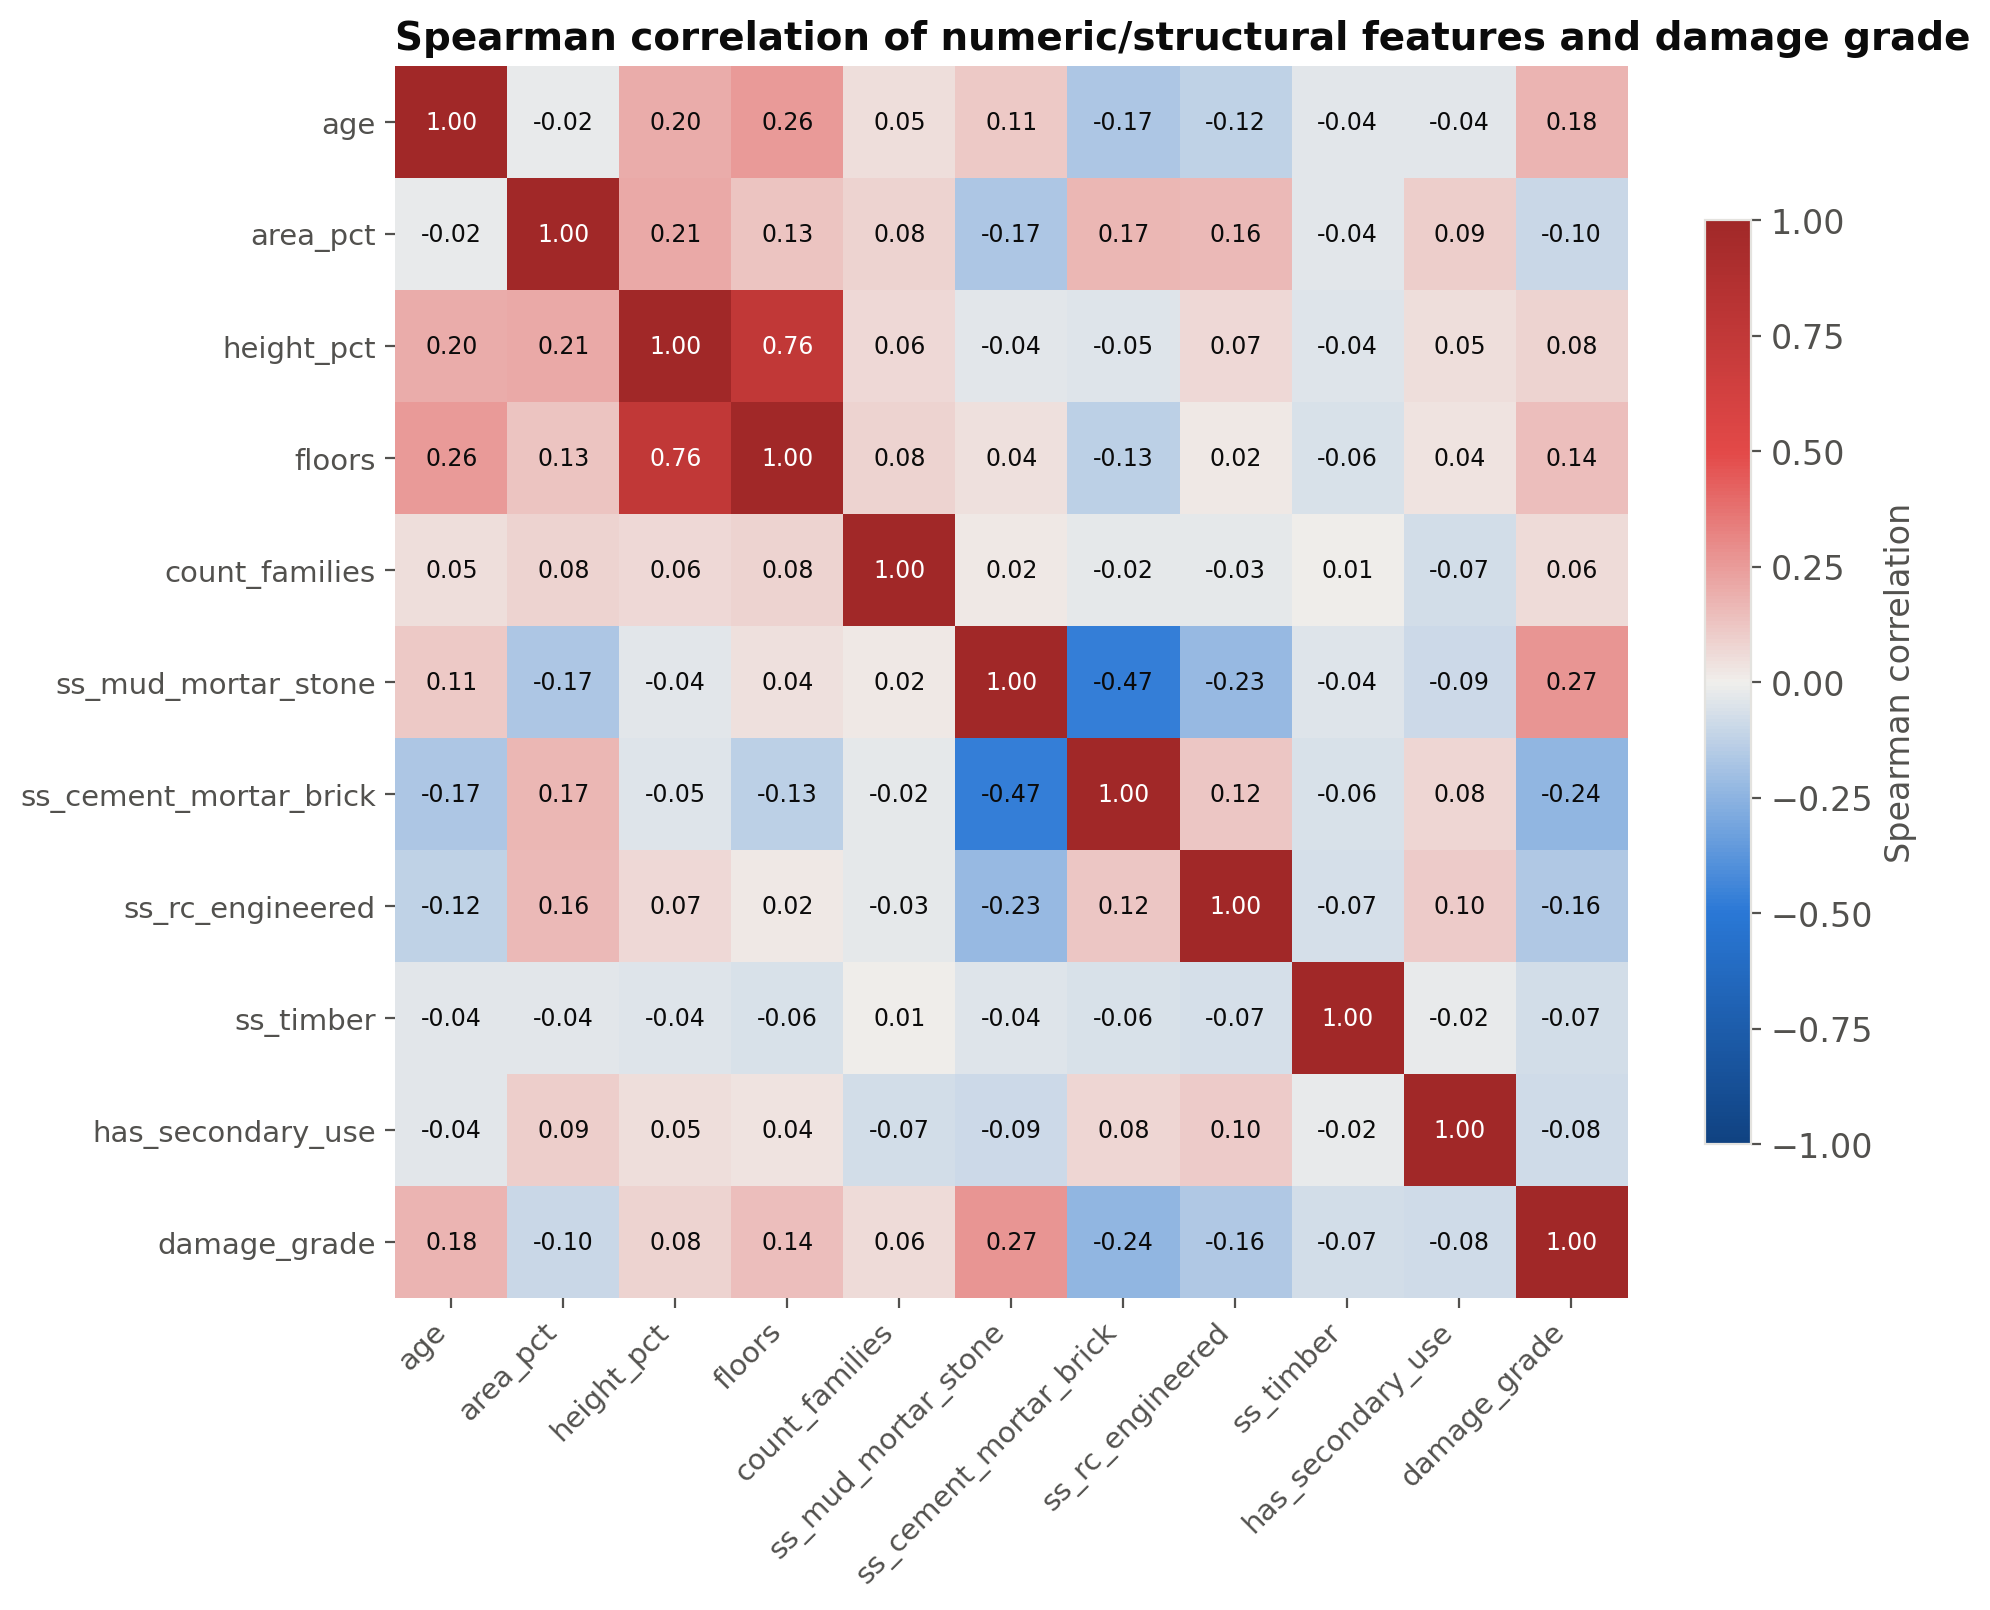

has_superstructure_cement_mortar_brick   -0.2392
has_superstructure_rc_engineered         -0.1622
has_superstructure_rc_non_engineered     -0.1472
count_floors_pre_eq                       0.1414
age                                       0.1752
has_superstructure_mud_mortar_stone       0.2725
dtype: float64

In [10]:
display(Image(plots.plot_correlation(train_df), width=800))
c = train_df[train_df["age"] != AGE_PLACEHOLDER].drop(columns=[ID_COL]).corr(method="spearman", numeric_only=True)
eda["spearman_with_target"] = c[TARGET].drop(TARGET).round(4).sort_values().to_dict()
eda["spearman_height_floors"] = float(c.loc["height_percentage", "count_floors_pre_eq"])
results["eda"] = eda
pd.Series(eda["spearman_with_target"]).sort_values().iloc[[0, 1, 2, -3, -2, -1]]

**Takeaway.** No single numeric feature correlates strongly with damage (|ρ| < 0.3). Engineered RC and cement-mortar brick are negatively associated and mud-mortar stone positively. Height and floor count are strongly collinear (ρ ≈ 0.76), and the L2 penalty in logistic regression handles that. Damage comes from combinations of weak signals, which is why a multivariate model is needed.

## 4. Preprocessing pipeline (fit inside every CV fold)

| Step | Columns | Transformation |
|---|---|---|
| `AgeCleaner` | `age` | flag `age == 995` → `age_is_placeholder`; replace by the **training-fold** median |
| `FeatureEngineer` | (E4 only) | row-wise engineered features |
| `log_num` | age, area_percentage, height_percentage | `log1p` → `StandardScaler` |
| `num` | count_floors_pre_eq, count_families (+ engineered) | `StandardScaler` |
| `cat` | 8 categorical columns | one-hot (`handle_unknown="ignore"`) |
| `geo1` | geo_level_1_id (E2+) | one-hot |
| `geo_te` | geo_level_2_id, geo_level_3_id (E3+) | `TargetEncoder(target_type="multiclass")`, internally cross-fitted |
| `bin` | 22 `has_*` flags + placeholder flag | passthrough |

Because all of this is inside one `Pipeline`, `cross_validate`/`GridSearchCV` refit every statistic (median, means, scales, categories and target encodings) on the training folds only.

In [11]:
example = make_model(E3).fit(X_tr.head(20000), y_tr.head(20000))
names = example.named_steps["pre"].get_feature_names_out()
print(len(names), "model features after preprocessing (E3).  Last 8:", list(names[-8:]))
example

103 model features after preprocessing (E3).  Last 8: ['geo_level_1_id_29', 'geo_level_1_id_30', 'geo_level_2_id_1', 'geo_level_2_id_2', 'geo_level_2_id_3', 'geo_level_3_id_1', 'geo_level_3_id_2', 'geo_level_3_id_3']


Pipeline(steps=[('age', AgeCleaner()), ('fe', FeatureEngineer()),
                ('pre',
                 ColumnTransformer(transformers=[('log_num',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'area_percentage',
                                                   'height_percentage']),
                                                 ('num', StandardScaler(),
                                                  ['count_floors_pre_eq',
                                                   'count_families']),...
                                                   'has_secondary_use_use_police',
                                                   'has_secondary_use_other',
                                                   'age_is_placeholder']),
                                                 ('geo1',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['geo_level_1_id']),
                                                 ('geo_te',
                                                  TargetEncoder(random_state=42,
                                                                target_type='multiclass'),
                                                  ['geo_level_2_id',
                                                   'geo_level_3_id'])],
                                   verbose_feature_names_out=False)),
                ('clf', LogisticRegression(max_iter=5000, random_state=42))])

## 5. Experiments (stratified 5-fold CV on the 80% split)
Each row reports mean ± std over the 5 folds. Micro-F1 equals accuracy for single-label multiclass problems and is the competition metric; macro-F1 weights the three grades equally.

In [12]:
experiments = {}

def run(cfg, short):
    t = time.time()
    r = run_cv(make_model(cfg), X_tr, y_tr, n_jobs=N_JOBS)
    cfg_d = asdict(cfg); cfg_d["engineered"] = list(cfg.engineered)
    experiments[cfg.name] = {"description": cfg.description, "short": short, "config": cfg_d, **r}
    print(f"{cfg.name:4s} micro-F1 {r['f1_micro']['mean']:.4f} ± {r['f1_micro']['std']:.4f} | "
          f"macro-F1 {r['f1_macro']['mean']:.4f} ± {r['f1_macro']['std']:.4f} | "
          f"max n_iter {r['max_n_iter']} | {time.time() - t:.0f}s")
    return r

run(E0, "baseline")
run(E1, "structural")
run(E2, "+ geo1 one-hot")
run(E3, "+ geo2/3 TE");

E0   micro-F1 0.5689 ± 0.0000 | macro-F1 0.2417 ± 0.0000 | max n_iter 0 | 16s


E1   micro-F1 0.5908 ± 0.0013 | macro-F1 0.4640 ± 0.0021 | max n_iter 143 | 32s


E2   micro-F1 0.6718 ± 0.0019 | macro-F1 0.5917 ± 0.0029 | max n_iter 162 | 40s


E3   micro-F1 0.7350 ± 0.0012 | macro-F1 0.6726 ± 0.0017 | max n_iter 258 | 69s


### E4 — engineered features (add-one ablation on top of E3)
Each candidate is added to E3 on its own. Because every run uses the same folds, we compare fold by fold. A feature is **kept** only if it raises mean micro-F1 *and* improves at least 4 of the 5 folds, which guards against keeping noise.

In [13]:
base = np.array(experiments["E3"]["f1_micro"]["folds"])
ablation = {}
for f in ENGINEERED_CANDIDATES:
    r = run_cv(make_model(E3.with_(name=f"E3+{f}", engineered=(f,))), X_tr, y_tr, n_jobs=N_JOBS)
    diff = np.array(r["f1_micro"]["folds"]) - base
    ablation[f] = {"f1_micro_mean": r["f1_micro"]["mean"], "f1_macro_mean": r["f1_macro"]["mean"],
                   "mean_gain": float(diff.mean()), "folds_improved": int((diff > 0).sum()),
                   "kept": bool(diff.mean() > 0 and (diff > 0).sum() >= 4),
                   "max_n_iter": r["max_n_iter"]}
kept = tuple(f for f in ENGINEERED_CANDIDATES if ablation[f]["kept"])
results["feature_ablation"] = {"candidates": ablation, "kept": list(kept),
                               "rule": "mean paired gain > 0 and improved in >= 4 of 5 folds"}
print("kept:", kept)
pd.DataFrame(ablation).T

kept: ('floors_x_log_age',)


,f1_micro_mean,f1_macro_mean,mean_gain,folds_improved,kept,max_n_iter
n_superstructure,0.734939,0.672664,-0.000043,2,False,267
log_area_height_ratio,0.734996,0.672764,0.000014,2,False,310
floors_x_log_age,0.735178,0.67319,0.000197,5,True,292
height_per_floor,0.735011,0.672667,0.000029,1,False,256


In [14]:
E4 = E3.with_(name="E4", description=f"E3 + engineered features ({', '.join(kept) or 'none kept'})",
              engineered=kept)
E5 = E4.with_(name="E5", description="E4 with class_weight='balanced'", class_weight="balanced")
E6 = E4.with_(name="E6", description="E4 as ordinal logistic (P(y>1), P(y>2))", ordinal=True)
run(E4, "+ engineered")
run(E5, "balanced")
run(E6, "ordinal");

E4   micro-F1 0.7352 ± 0.0010 | macro-F1 0.6732 ± 0.0014 | max n_iter 292 | 81s


E5   micro-F1 0.6909 ± 0.0011 | macro-F1 0.6644 ± 0.0008 | max n_iter 259 | 86s


E6   micro-F1 0.7346 ± 0.0012 | macro-F1 0.6728 ± 0.0017 | max n_iter 175 | 49s


Best configuration for tuning: E4 - E3 + engineered features (floors_x_log_age)


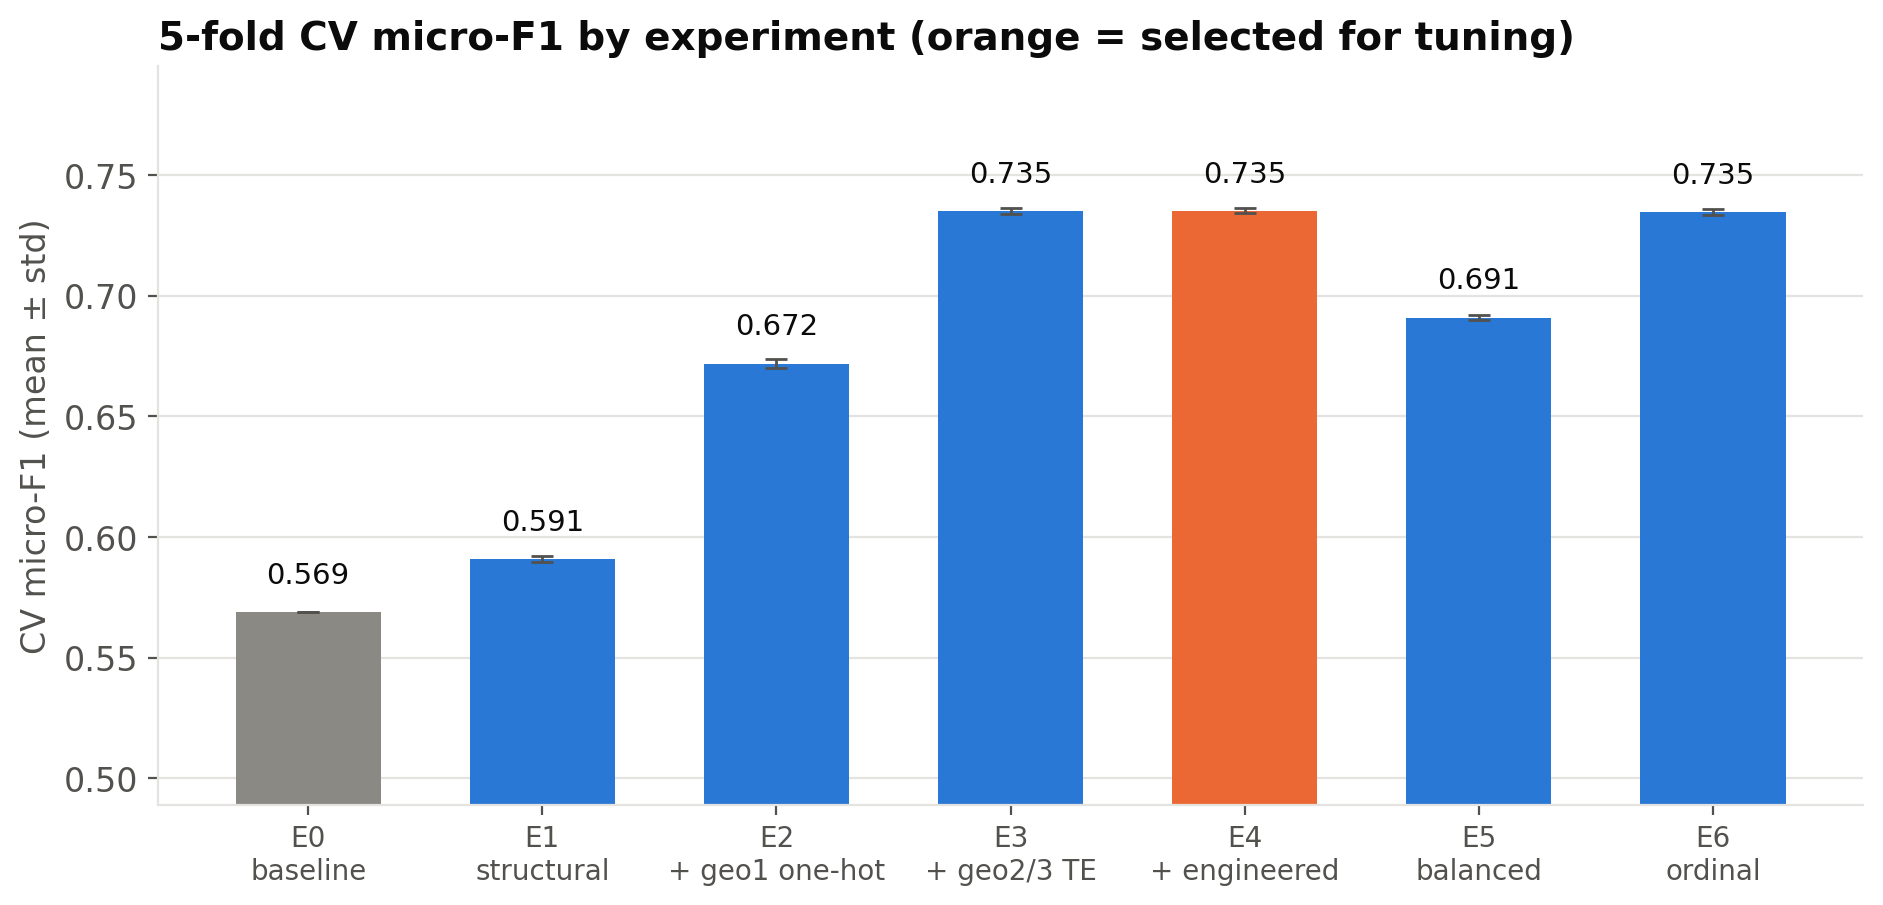

,name,description,short,f1_micro_mean,f1_micro_std,f1_macro_mean,f1_macro_std,recall_1,recall_2,recall_3,max_n_iter,fit_time_s
0,E0,Majority-class baseline,baseline,0.5689,0.0000,0.2417,0.0000,0.0000,1.0000,0.0000,0,0.1584
1,E1,"Logistic regression, structural features only",structural,0.5908,0.0013,0.4640,0.0021,0.3166,0.8804,0.1773,143,10.3937
2,E2,E1 + one-hot geo_level_1_id,+ geo1 one-hot,0.6718,0.0019,0.5917,0.0029,0.3568,0.8165,0.5167,162,13.5984
3,E3,E2 + target-encoded geo_level_2/3_id,+ geo2/3 TE,0.7350,0.0012,0.6726,0.0017,0.4683,0.8448,0.6250,258,23.9482
4,E4,E3 + engineered features (floors_x_log_age),+ engineered,0.7352,0.0010,0.6732,0.0014,0.4700,0.8449,0.6250,292,28.4331
5,E5,E4 with class_weight='balanced',balanced,0.6909,0.0011,0.6644,0.0008,0.8250,0.6470,0.7269,259,29.8260
6,E6,"E4 as ordinal logistic (P(y>1), P(y>2))",ordinal,0.7346,0.0012,0.6728,0.0017,0.4703,0.8437,0.6251,175,16.6610


In [15]:
table = pd.DataFrame([{
    "name": k, "description": v["description"], "short": v["short"],
    "f1_micro_mean": v["f1_micro"]["mean"], "f1_micro_std": v["f1_micro"]["std"],
    "f1_macro_mean": v["f1_macro"]["mean"], "f1_macro_std": v["f1_macro"]["std"],
    **{f"recall_{c}": v[f"recall_{c}"]["mean"] for c in CLASSES},
    "max_n_iter": v["max_n_iter"], "fit_time_s": v["fit_time_s"]} for k, v in experiments.items()])
candidates = table[table["name"].isin(["E4", "E5", "E6"])]
best_name = candidates.sort_values("f1_micro_mean", ascending=False)["name"].iloc[0]
best_cfg = {"E4": E4, "E5": E5, "E6": E6}[best_name]
print("Best configuration for tuning:", best_name, "-", best_cfg.description)
display(Image(plots.plot_experiments(table, best_name), width=950))
table.round(4)

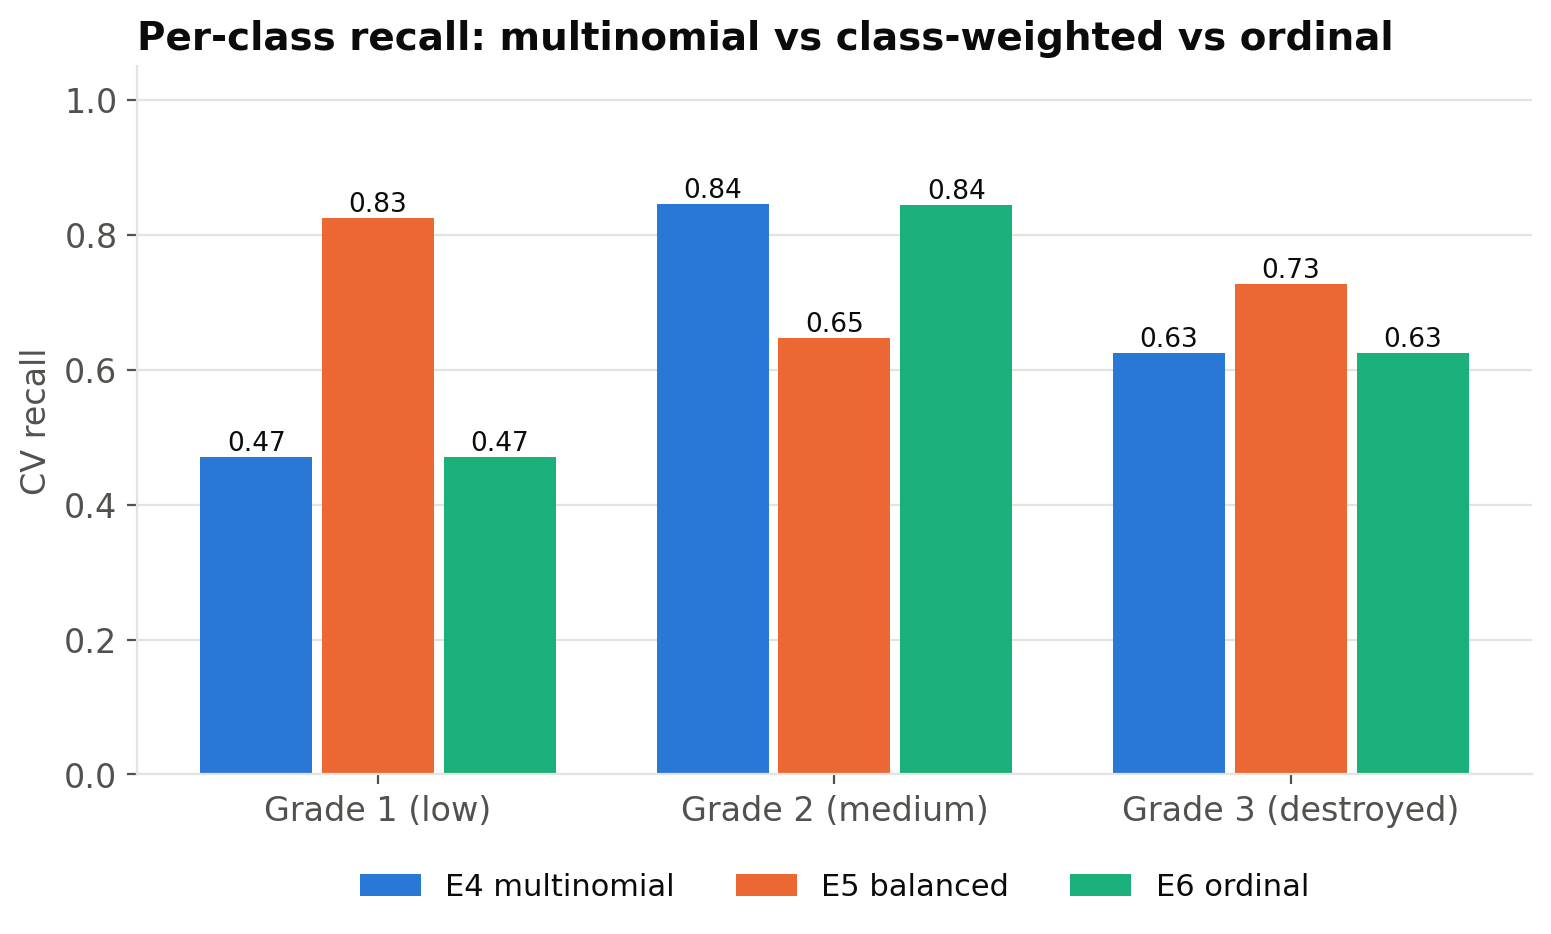

In [16]:
recall_rows = table[table["name"].isin(["E4", "E5", "E6"])].assign(
    label=lambda d: d["name"].map({"E4": "E4 multinomial", "E5": "E5 balanced", "E6": "E6 ordinal"}))
display(Image(plots.plot_recall_comparison(recall_rows), width=800))

## 6. Tune `C` with GridSearchCV on the best configuration
The grid is log-spaced from 0.01 to 100 and scored by micro-F1. A custom scorer records the solver iterations of every fold, so convergence can be checked even though folds run in worker processes.

best C = 0.3, CV micro-F1 = 0.7354  (674s)


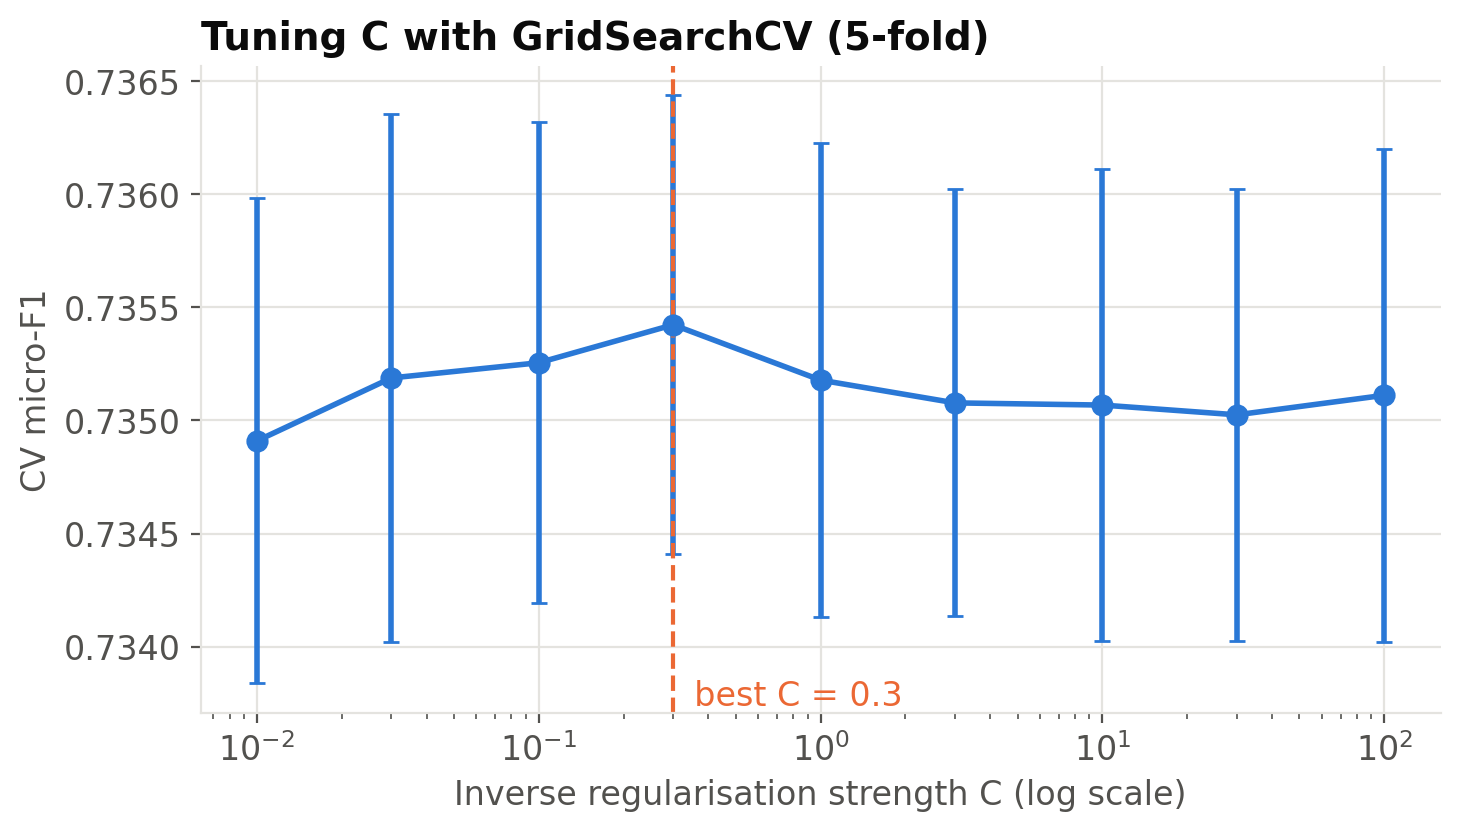

,C,mean,std,f1_macro_mean,max_n_iter
0,0.01,0.7349,0.0011,0.6709,96.0
1,0.03,0.7352,0.0012,0.6723,110.0
2,0.10,0.7353,0.0011,0.6730,175.0
3,0.30,0.7354,0.0010,0.6733,232.0
4,1.00,0.7352,0.0010,0.6732,292.0
5,3.00,0.7351,0.0009,0.6731,317.0
6,10.00,0.7351,0.0010,0.6732,324.0
7,30.00,0.7350,0.0010,0.6731,336.0
8,100.00,0.7351,0.0011,0.6732,337.0


In [17]:
C_GRID = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
grid = GridSearchCV(make_model(best_cfg), {"clf__C": C_GRID}, cv=cv_splitter(),
                    scoring={"f1_micro": "f1_micro", "f1_macro": "f1_macro", "n_iter": n_iter_scorer},
                    refit="f1_micro", n_jobs=N_JOBS, error_score="raise")
t = time.time()
grid.fit(X_tr, y_tr)          # refit of the best C happens in this process -> warnings are errors
cvr = pd.DataFrame(grid.cv_results_)
tuning = pd.DataFrame({"C": cvr["param_clf__C"].astype(float),
                       "mean": cvr["mean_test_f1_micro"], "std": cvr["std_test_f1_micro"],
                       "f1_macro_mean": cvr["mean_test_f1_macro"],
                       "max_n_iter": cvr[[f"split{i}_test_n_iter" for i in range(5)]].max(axis=1)})
best_C = float(grid.best_params_["clf__C"])
final_model = grid.best_estimator_
results["tuning"] = {
    "config": best_name, "grid": C_GRID, "best_C": best_C,
    "best_f1_micro_mean": float(grid.best_score_),
    "best_f1_micro_std": float(tuning.loc[tuning["C"] == best_C, "std"].iloc[0]),
    "best_f1_macro_mean": float(tuning.loc[tuning["C"] == best_C, "f1_macro_mean"].iloc[0]),
    "rows": tuning.to_dict(orient="records"), "time_s": float(time.time() - t),
    "refit_n_iter": max_n_iter(final_model),
}
print(f"best C = {best_C}, CV micro-F1 = {grid.best_score_:.4f}  ({time.time() - t:.0f}s)")
display(Image(plots.plot_c_tuning(tuning, best_C), width=700))
tuning.round(4)

In [18]:
all_iters = [v["max_n_iter"] for v in experiments.values()] + \
            [v["max_n_iter"] for v in ablation.values()] + \
            list(tuning["max_n_iter"]) + [results["tuning"]["refit_n_iter"]]
results["convergence"] = {"max_iter_allowed": MAX_ITER, "max_n_iter_observed": int(max(all_iters)),
                          "all_converged": bool(max(all_iters) < MAX_ITER)}
assert results["convergence"]["all_converged"], "a fit hit max_iter"
results["convergence"]

{'max_iter_allowed': 5000, 'max_n_iter_observed': 337, 'all_converged': True}

## 7. Experiment table

In [19]:
results["experiments"] = experiments
results["best_config"] = {"name": best_name, "description": best_cfg.description}
summary = table[["name", "description", "f1_micro_mean", "f1_micro_std", "f1_macro_mean",
                 "f1_macro_std", "recall_1", "recall_2", "recall_3"]].copy()
summary.loc[len(summary)] = [f"{best_name} tuned", f"{best_cfg.description}, C={best_C:g}",
                             results["tuning"]["best_f1_micro_mean"], results["tuning"]["best_f1_micro_std"],
                             results["tuning"]["best_f1_macro_mean"], np.nan, np.nan, np.nan, np.nan]
save_results(results)   # checkpoint
summary.round(4)

,name,description,f1_micro_mean,f1_micro_std,f1_macro_mean,f1_macro_std,recall_1,recall_2,recall_3
0,E0,Majority-class baseline,0.5689,0.0000,0.2417,0.0000,0.0000,1.0000,0.0000
1,E1,"Logistic regression, structural features only",0.5908,0.0013,0.4640,0.0021,0.3166,0.8804,0.1773
2,E2,E1 + one-hot geo_level_1_id,0.6718,0.0019,0.5917,0.0029,0.3568,0.8165,0.5167
3,E3,E2 + target-encoded geo_level_2/3_id,0.7350,0.0012,0.6726,0.0017,0.4683,0.8448,0.6250
4,E4,E3 + engineered features (floors_x_log_age),0.7352,0.0010,0.6732,0.0014,0.4700,0.8449,0.6250
5,E5,E4 with class_weight='balanced',0.6909,0.0011,0.6644,0.0008,0.8250,0.6470,0.7269
6,E6,"E4 as ordinal logistic (P(y>1), P(y>2))",0.7346,0.0012,0.6728,0.0017,0.4703,0.8437,0.6251
7,E4 tuned,"E3 + engineered features (floors_x_log_age), C...",0.7354,0.0010,0.6733,NaN,NaN,NaN,NaN


## 8. Final evaluation on the holdout (used exactly once)

Holdout micro-F1 = 0.7405   macro-F1 = 0.6798


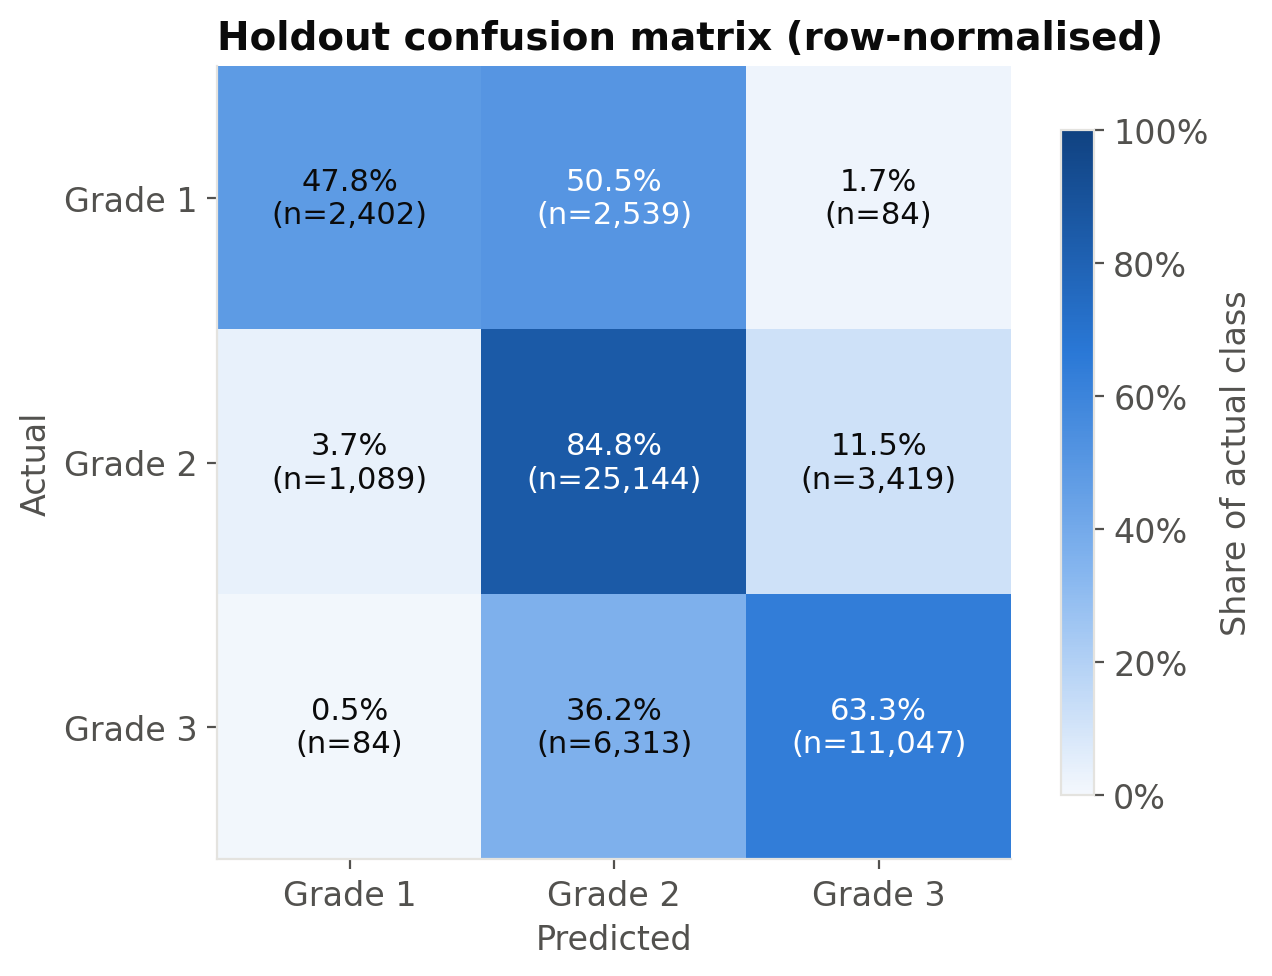

,precision,recall,f1,support
1,0.672,0.478,0.559,5025.0
2,0.740,0.848,0.790,29652.0
3,0.759,0.633,0.691,17444.0


In [20]:
assert "holdout" not in results, "holdout already used"
y_pred = final_model.predict(X_ho)
proba = final_model.predict_proba(X_ho)
holdout = classification_summary(y_ho, y_pred)
holdout["predicted_class_share"] = {str(c): float((y_pred == c).mean()) for c in CLASSES}
holdout["model"] = f"{best_name} tuned (C={best_C:g})"
results["holdout"] = holdout
print(f"Holdout micro-F1 = {holdout['f1_micro']:.4f}   macro-F1 = {holdout['f1_macro']:.4f}")
display(Image(plots.plot_confusion(holdout["confusion_matrix_normalised"], holdout["confusion_matrix"]), width=560))
pd.DataFrame(holdout["per_class"]).T.round(3)

## 9. Prioritisation analysis — does the ranking help inspectors?
Holdout buildings are ranked by predicted P(grade 3). We then ask what share of the truly destroyed (grade-3) buildings is found if inspectors visit the top x% first, compared with visiting buildings in random order.

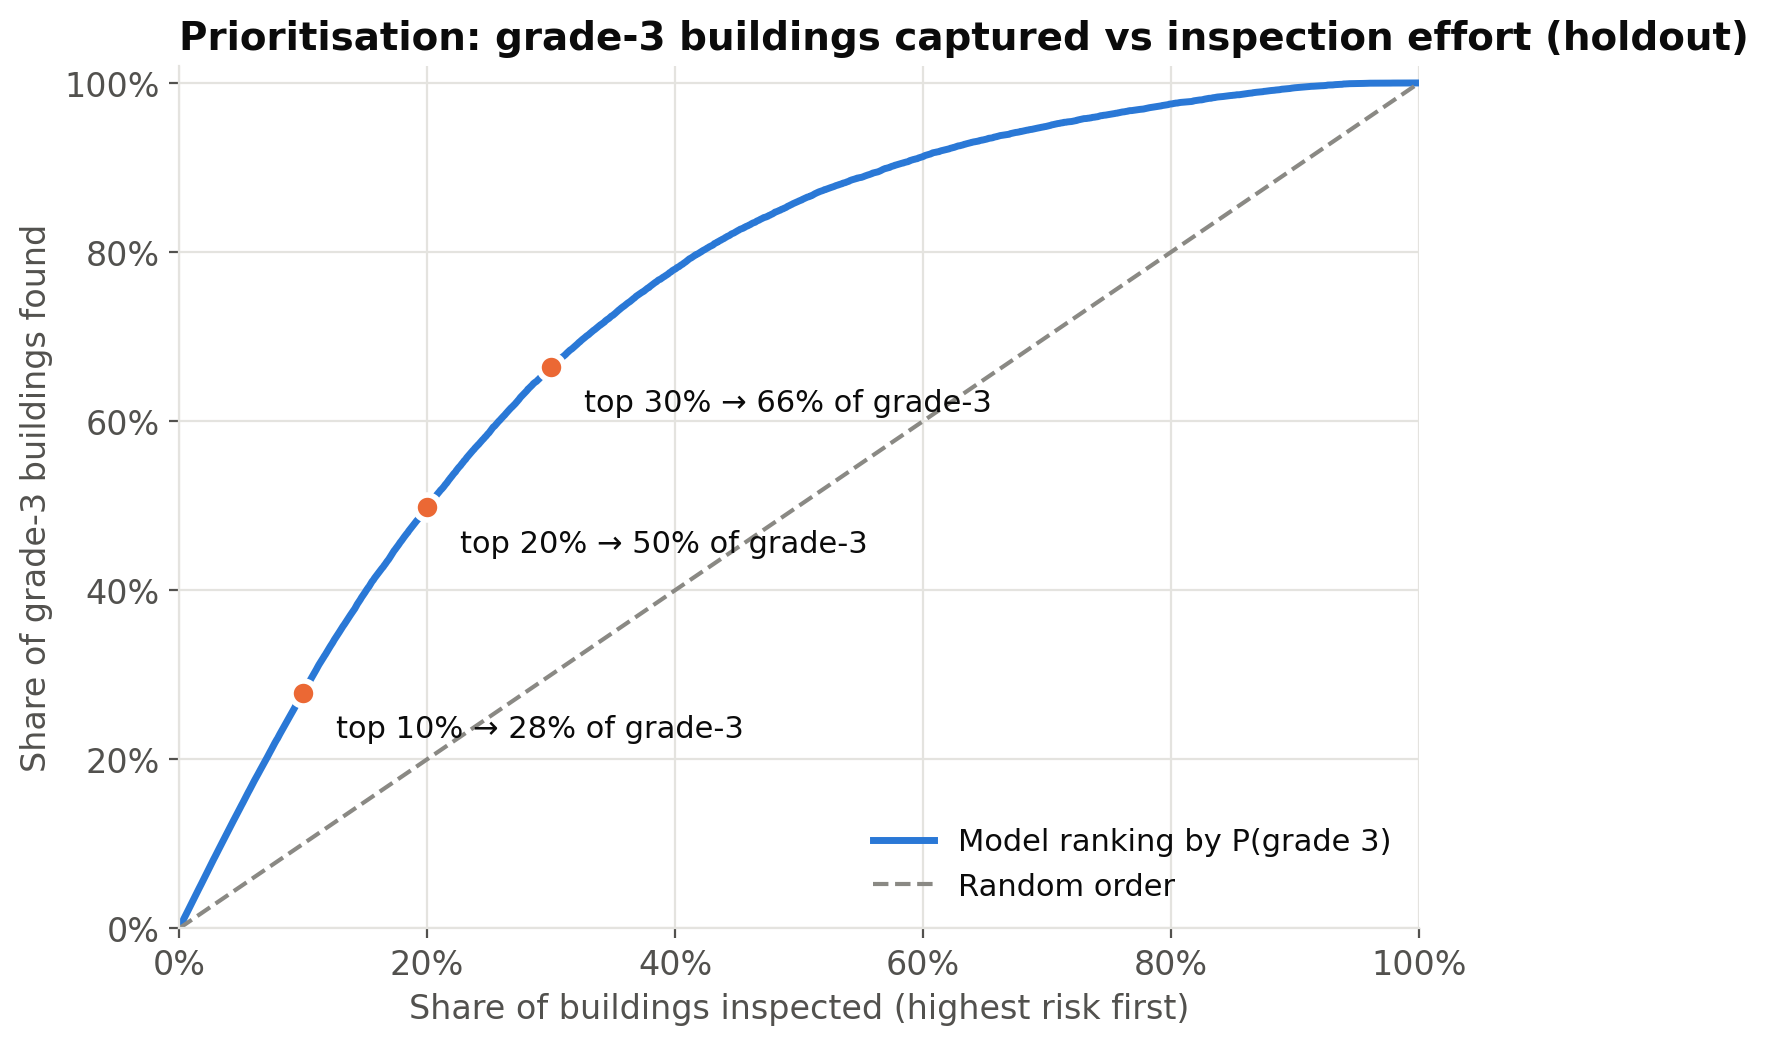

,capture_rate,lift,precision_in_top,n_inspected
10,0.279,2.789,0.933,5212.0
20,0.498,2.490,0.833,10424.0
30,0.664,2.213,0.741,15636.0


In [21]:
classes = list(final_model.classes_)
p3 = proba[:, classes.index(3)]
share_insp, share_capt, prio = capture_curve(y_ho.values, p3)
results["prioritisation"] = prio
display(Image(plots.plot_capture(share_insp, share_capt, prio), width=700))
pd.DataFrame(prio["at_fraction"]).T.round(3)

## 10. Interpretation: which building characteristics drive grade-3 damage?
We read the grade-3 row of the final multinomial model as odds ratios. Location features are summarised separately because they stand in for shaking intensity. Flags present in fewer than 1% of training buildings (for example a school as secondary use) are also excluded, because their coefficients rest on a few dozen buildings and are unstable.

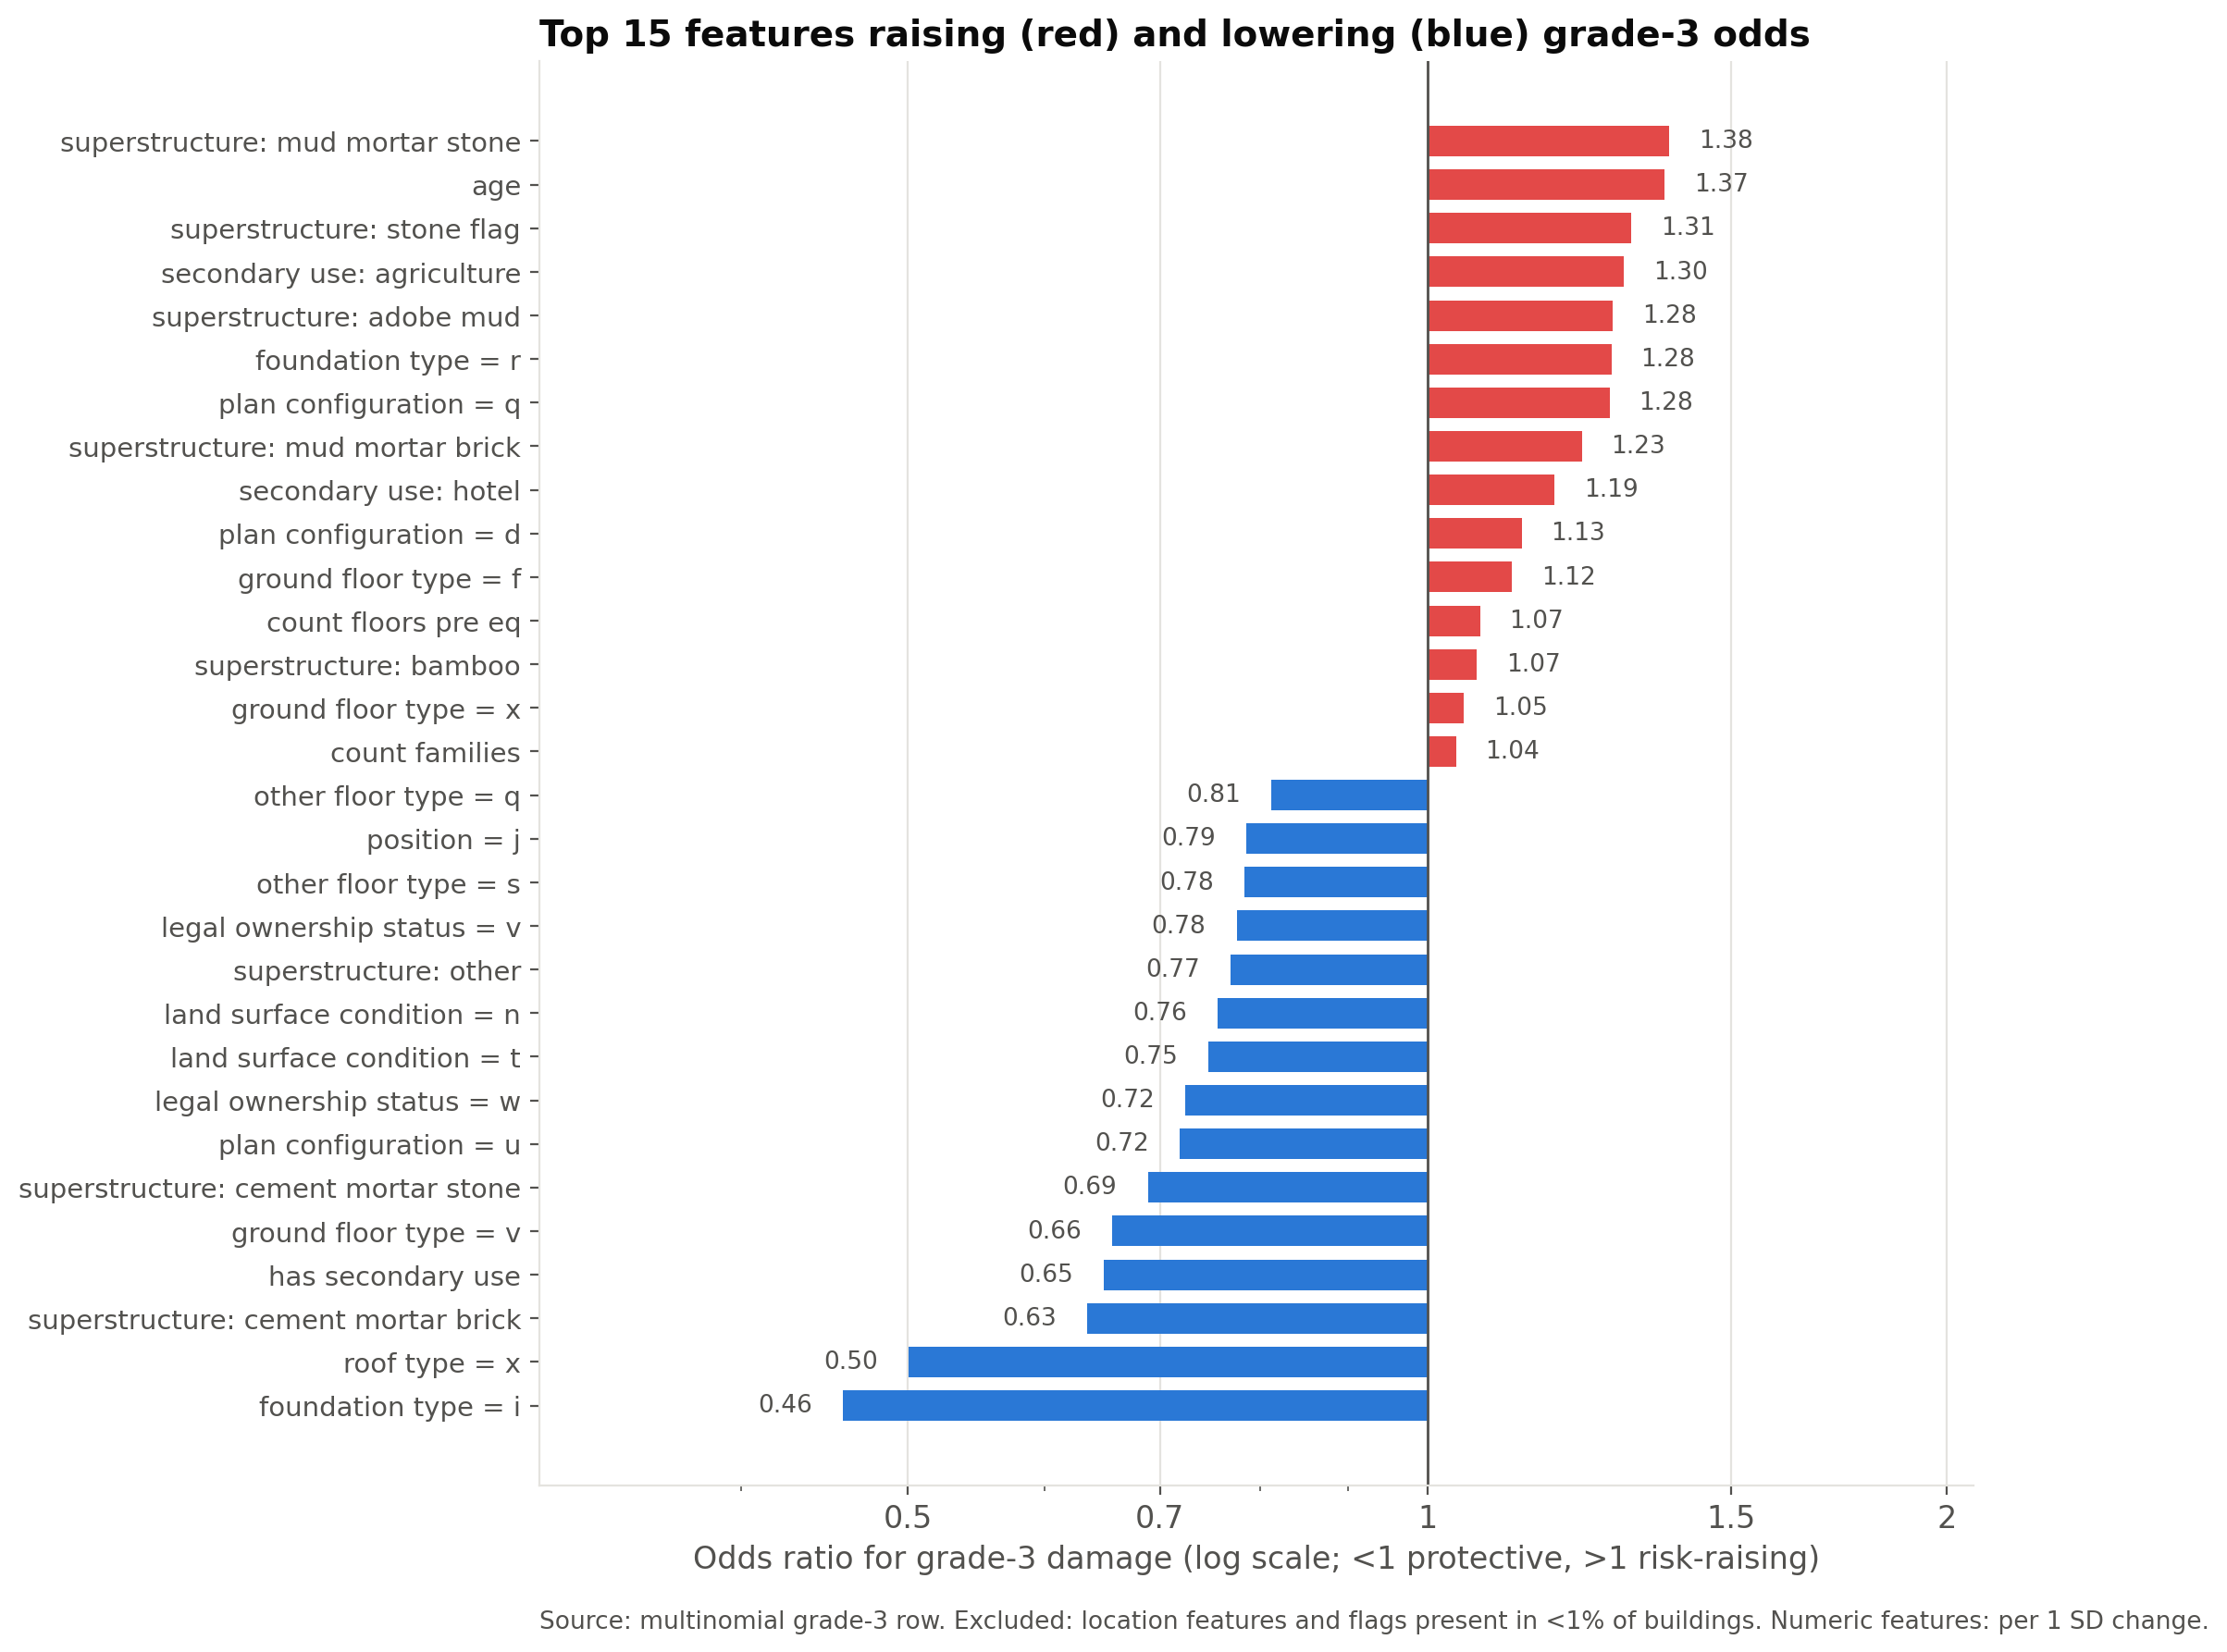

,feature,coef,odds_ratio,prevalence
10,has_superstructure_mud_mortar_stone,0.323,1.382,0.762
11,age,0.317,1.373,NaN
13,has_superstructure_stone_flag,0.273,1.313,0.034
15,has_secondary_use_agriculture,0.262,1.300,0.064
17,has_superstructure_adobe_mud,0.248,1.281,0.089
18,foundation_type_r,0.246,1.279,0.841
19,plan_configuration_q,0.244,1.276,0.022
21,has_superstructure_mud_mortar_brick,0.206,1.229,0.068
86,legal_ownership_status_w,-0.323,0.724,0.010
87,plan_configuration_u,-0.330,0.719,0.014


In [22]:
MIN_PREV = 0.01
coefs = grade3_coefficients(final_model, X_tr)
display(Image(plots.plot_coefficients(coefs, top=15, source=coefs.attrs["source"], min_prevalence=MIN_PREV), width=850))
rare = coefs["prevalence"] < MIN_PREV
struct = coefs[~coefs["is_location"] & ~rare]
loc = coefs[coefs["is_location"]]
cols = ["feature", "coef", "odds_ratio", "prevalence"]
clean = lambda df: [{k: (None if (isinstance(v, float) and np.isnan(v)) else v) for k, v in r.items()}
                    for r in df[cols].to_dict(orient="records")]
materials = ["has_superstructure_mud_mortar_stone", "has_superstructure_stone_flag", "has_superstructure_adobe_mud",
             "has_superstructure_rc_engineered", "has_superstructure_cement_mortar_brick", "has_superstructure_timber"]
results["coefficients"] = {
    "source": coefs.attrs["source"], "min_prevalence": MIN_PREV,
    "top_raising": clean(struct.head(15)),
    "top_lowering": clean(struct.tail(15).iloc[::-1]),
    "location_top": clean(loc.reindex(loc["coef"].abs().sort_values(ascending=False).index).head(5)),
    "excluded_rare_top": clean(coefs[rare & ~coefs["is_location"]].reindex(
        coefs.loc[rare & ~coefs["is_location"], "coef"].abs().sort_values(ascending=False).index).head(5)),
    "materials": {m: clean(coefs[coefs["feature"] == m])[0] for m in materials},
    "n_features": int(len(coefs)), "n_excluded_rare": int((rare & ~coefs["is_location"]).sum()),
}
pd.concat([struct.head(8), struct.tail(8)])[cols].round(3)

In [23]:
# rare flags that were excluded from the chart (large but unreliable coefficients)
pd.DataFrame(results["coefficients"]["excluded_rare_top"]).round(4)

,feature,coef,odds_ratio,prevalence
0,has_secondary_use_school,0.7334,2.0821,0.0004
1,plan_configuration_c,-0.4870,0.6145,0.0013
2,plan_configuration_m,-0.3795,0.6842,0.0002
3,plan_configuration_n,0.3493,1.4180,0.0001
4,has_secondary_use_gov_office,-0.2851,0.7519,0.0001


## 11. Submission file — refit on all labelled data

In [24]:
final_cfg = best_cfg.with_(C=best_C)
t = time.time()
sub_model = make_model(final_cfg).fit(*split_xy(df))
test_pred = sub_model.predict(test_df.drop(columns=[ID_COL])).astype(int)
submission = pd.DataFrame({ID_COL: test_df[ID_COL].values, "damage_grade": test_pred})
SUBMISSION_PATH.parent.mkdir(exist_ok=True)
submission.to_csv(SUBMISSION_PATH, index=False)

check = pd.read_csv(SUBMISSION_PATH)
raw = SUBMISSION_PATH.read_text().splitlines()
assert list(check.columns) == [ID_COL, "damage_grade"] and len(check) == 86_868
assert check["damage_grade"].dtype.kind == "i" and set(check["damage_grade"]) <= {1, 2, 3}
assert (check[ID_COL].values == test_df[ID_COL].values).all() and not any(".0" in r for r in raw[1:50])
results["submission"] = {"path": "outputs/submission.csv", "n_rows": int(len(check)),
                         "columns": list(check.columns), "refit_rows": int(len(df)),
                         "refit_n_iter": max_n_iter(sub_model), "C": best_C, "config": best_name,
                         "predicted_class_share": {str(k): float(v) for k, v in
                                                   check["damage_grade"].value_counts(normalize=True).sort_index().items()}}
print(raw[:4], f"... {len(check):,} rows  ({time.time() - t:.0f}s)")

['building_id,damage_grade', '300051,3', '99355,2', '890251,3'] ... 86,868 rows  (35s)


## 12. Save `outputs/results.json` (single source of truth)

In [25]:
results["meta"]["runtime_minutes"] = round((time.time() - T_START) / 60, 1)
save_results(results)
print("wrote", RESULTS_PATH, f"({RESULTS_PATH.stat().st_size / 1024:.0f} KB)")
print(f"Headline: holdout micro-F1 {results['holdout']['f1_micro']:.4f}, macro-F1 {results['holdout']['f1_macro']:.4f}; "
      f"top-20% inspection captures {results['prioritisation']['at_fraction']['20']['capture_rate']:.1%} of grade-3 buildings")

wrote D:\NTU-python\Project\outputs\results.json (35 KB)
Headline: holdout micro-F1 0.7405, macro-F1 0.6798; top-20% inspection captures 49.8% of grade-3 buildings


## 13. Conclusion

In [26]:
from IPython.display import Markdown
R = results
e, h, p = R["experiments"], R["holdout"], R["prioritisation"]["at_fraction"]
display(Markdown(f"""
* **Location is the dominant signal.** Structure alone lifts CV micro-F1 from {e['E0']['f1_micro']['mean']:.3f} (majority baseline) to {e['E1']['f1_micro']['mean']:.3f}. One-hot regions add {100*(e['E2']['f1_micro']['mean']-e['E1']['f1_micro']['mean']):+.1f} pp, and cross-fitted target encoding of geo levels 2 and 3 adds another {100*(e['E3']['f1_micro']['mean']-e['E2']['f1_micro']['mean']):+.1f} pp.
* **Engineered features barely matter** ({100*(e['E4']['f1_micro']['mean']-e['E3']['f1_micro']['mean']):+.2f} pp; kept: {', '.join(R['feature_ablation']['kept']) or 'none'}).
* **Class weighting** raises grade-1 recall ({e['E4']['recall_1']['mean']:.2f} → {e['E5']['recall_1']['mean']:.2f}) but changes micro-F1 by {100*(e['E5']['f1_micro']['mean']-e['E4']['f1_micro']['mean']):+.2f} pp and macro-F1 by {100*(e['E5']['f1_macro']['mean']-e['E4']['f1_macro']['mean']):+.2f} pp. Grade-2 buildings get pulled into grade 1, so it is a policy trade-off, not an improvement.
* **The ordinal model** (two cumulative binary LRs) is no better than the multinomial model ({100*(e['E6']['f1_micro']['mean']-e['E4']['f1_micro']['mean']):+.2f} pp micro-F1). With three classes, the softmax model already captures the ordering, so this is a negative result.
* **Final model** {R['best_config']['name']} with C = {R['tuning']['best_C']:g}: holdout micro-F1 **{h['f1_micro']:.4f}**, macro-F1 **{h['f1_macro']:.4f}**, close to the CV estimate ({R['tuning']['best_f1_micro_mean']:.4f}).
* **Prioritisation:** inspecting the top 10% / 20% / 30% of buildings by P(grade 3) finds {p['10']['capture_rate']:.1%} / {p['20']['capture_rate']:.1%} / {p['30']['capture_rate']:.1%} of grade-3 buildings, against 10% / 20% / 30% for a random order.
"""))


* **Location is the dominant signal.** Structure alone lifts CV micro-F1 from 0.569 (majority baseline) to 0.591. One-hot regions add +8.1 pp, and cross-fitted target encoding of geo levels 2 and 3 adds another +6.3 pp.
* **Engineered features barely matter** (+0.02 pp; kept: floors_x_log_age).
* **Class weighting** raises grade-1 recall (0.47 → 0.83) but changes micro-F1 by -4.43 pp and macro-F1 by -0.88 pp. Grade-2 buildings get pulled into grade 1, so it is a policy trade-off, not an improvement.
* **The ordinal model** (two cumulative binary LRs) is no better than the multinomial model (-0.06 pp micro-F1). With three classes, the softmax model already captures the ordering, so this is a negative result.
* **Final model** E4 with C = 0.3: holdout micro-F1 **0.7405**, macro-F1 **0.6798**, close to the CV estimate (0.7354).
* **Prioritisation:** inspecting the top 10% / 20% / 30% of buildings by P(grade 3) finds 27.9% / 49.8% / 66.4% of grade-3 buildings, against 10% / 20% / 30% for a random order.
